# Part 4: Limit Order Book Feature Engineering

*"Price is what you pay. Value is what you get. But the order book shows you what everyone else is willing to pay right now."*

---

Parts 1 through 3 worked entirely from end-of-day data: closing prices, daily returns, and macro indicators. Every feature was built from what *happened* — price changes already recorded, volatility already realised, volume already traded. The limitation is obvious: by the time the closing price is set, all the intraday information that drove it has been discarded.

The limit order book changes that completely. A limit order is a standing instruction: *I am willing to buy 500 shares of NVDA at \$440.00 or better*. The book is the live collection of all such instructions, updated thousands of times per second. It tells you not just what prices traded, but what buyers and sellers *intend* to do — before the trade happens. That forward-looking quality is what makes LOB features fundamentally different from price-based features.

This notebook has two goals. The first is to understand the data structure — what each record means, what the action codes represent, how to read the book at a given moment in time. The second is to build features: spread and mid-price at level 1, order book imbalance at multiple levels, order flow imbalance, and depth profile metrics. We then compare the same features across a calm period (October 2023) and a stress period (August 5–9, 2024 — the yen carry trade unwind), where the book behaves very differently.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

LOB_DIR = 'data/lob'

# Action codes from Databento ITCH feed
ACTION_LABELS = {'A': 'Add order', 'C': 'Cancel order', 'T': 'Trade', 'F': 'Fill (partial)'}
SIDE_LABELS   = {'B': 'Bid (buy)', 'A': 'Ask (sell)', 'N': 'None (trade)'}


## Understanding the Data

The data comes from NASDAQ's ITCH feed — the raw order-by-order record of every event that changes the book. Each row is not a trade; it is an **event**: an order added, an order cancelled, or an order executed. The book state (bid and ask prices and sizes at up to 10 levels) is recorded *after* each event, so you always know the full book at every point in time.

The key columns are:

**`action`** — what happened: `A` = new limit order added, `C` = limit order cancelled, `T` = trade (an order was matched and executed), `F` = partial fill.

**`side`** — which side was affected: `B` = bid (a buyer's order), `A` = ask (a seller's order), `N` = neither (a cross-trade).

**`bid_px_00` / `ask_px_00`** — best bid and ask price after this event (level 0 = top of book).

**`bid_sz_00` / `ask_sz_00`** — total shares sitting at the best bid and ask.

**`bid_px_01` ... `bid_px_09`** — second through tenth best bid price levels (mbp-10 only). Same for ask.

**`ts_event`** — nanosecond-precision UTC timestamp of the event.


In [2]:
# Load mbp-1 for NVDA (calm period)
nvda = pd.read_parquet(f'{LOB_DIR}/lob_mbp1_NVDA_calm_oct2023.parquet')
nvda.index = nvda.index.tz_convert('US/Eastern')  # convert to market time
nvda['ts_event'] = nvda['ts_event'].dt.tz_convert('US/Eastern')

print(f'NVDA calm: {len(nvda):,} rows  |  {nvda.index[0]}  to  {nvda.index[-1]}')
print(f'Columns  : {list(nvda.columns)}')
nvda[['ts_event','action','side','price','size','bid_px_00','ask_px_00','bid_sz_00','ask_sz_00']].head(10)


NVDA calm: 4,761,024 rows  |  2023-10-02 04:00:00.010216826-04:00  to  2023-10-12 19:59:56.718274004-04:00
Columns  : ['ts_event', 'rtype', 'publisher_id', 'instrument_id', 'action', 'side', 'depth', 'price', 'size', 'flags', 'ts_in_delta', 'sequence', 'bid_px_00', 'ask_px_00', 'bid_sz_00', 'ask_sz_00', 'bid_ct_00', 'ask_ct_00', 'symbol']


,ts_event,action,side,price,size,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00
ts_recv,,,,,,,,,
2023-10-02 04:00:00.010216826-04:00,2023-10-02 04:00:00.010046931-04:00,A,N,403.93,50,403.93,NaN,50,0
2023-10-02 04:00:00.018643514-04:00,2023-10-02 04:00:00.018474714-04:00,A,B,440.77,100,440.77,NaN,100,0
2023-10-02 04:00:00.018676033-04:00,2023-10-02 04:00:00.018507995-04:00,A,A,441.60,100,440.77,441.60,100,100
2023-10-02 04:00:00.019557602-04:00,2023-10-02 04:00:00.019388560-04:00,C,B,440.77,100,403.93,441.60,50,100
2023-10-02 04:00:00.019593199-04:00,2023-10-02 04:00:00.019424923-04:00,A,B,440.73,100,440.73,441.60,100,100
2023-10-02 04:00:00.020198499-04:00,2023-10-02 04:00:00.020030451-04:00,C,B,440.73,100,403.93,441.60,50,100
2023-10-02 04:00:00.020217060-04:00,2023-10-02 04:00:00.020047773-04:00,C,A,441.60,100,403.93,NaN,50,0
2023-10-02 04:00:00.020290689-04:00,2023-10-02 04:00:00.020123216-04:00,A,A,441.63,100,403.93,441.63,50,100
2023-10-02 04:00:00.020794784-04:00,2023-10-02 04:00:00.020626929-04:00,C,A,441.63,100,403.93,NaN,50,0


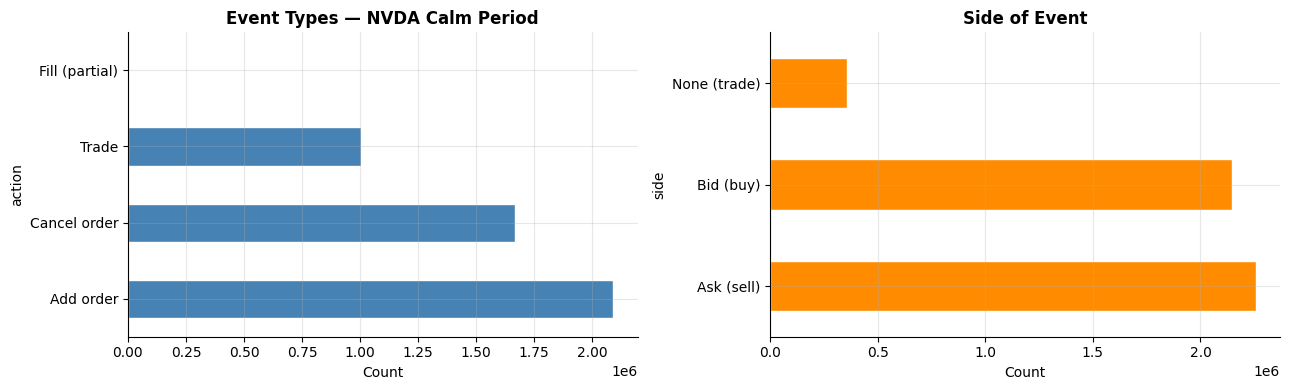

Most events are order additions (A) and cancellations (C).
Trades (T) are a small fraction — most limit orders are cancelled before execution.
Fill rate: 21.1% of all events are actual trades


In [3]:
# Event type breakdown
action_counts = nvda['action'].map(ACTION_LABELS).value_counts()
side_counts   = nvda['side'].map(SIDE_LABELS).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
action_counts.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Event Types — NVDA Calm Period', fontweight='bold')
axes[0].set_xlabel('Count')

side_counts.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Side of Event', fontweight='bold')
axes[1].set_xlabel('Count')
plt.tight_layout()
plt.show()

print('Most events are order additions (A) and cancellations (C).')
print('Trades (T) are a small fraction — most limit orders are cancelled before execution.')
total = len(nvda)
trades = (nvda['action'] == 'T').sum()
print(f'Fill rate: {trades/total:.1%} of all events are actual trades')


## Visualizing the Book

The order book at any moment can be visualised as a horizontal bar chart: bids on the left (buy orders), asks on the right (sell orders), price increasing away from centre. The gap between the best bid and best ask is the **spread** — the cost of an immediate round-trip trade. The height of each bar is the total quantity sitting at that price level.


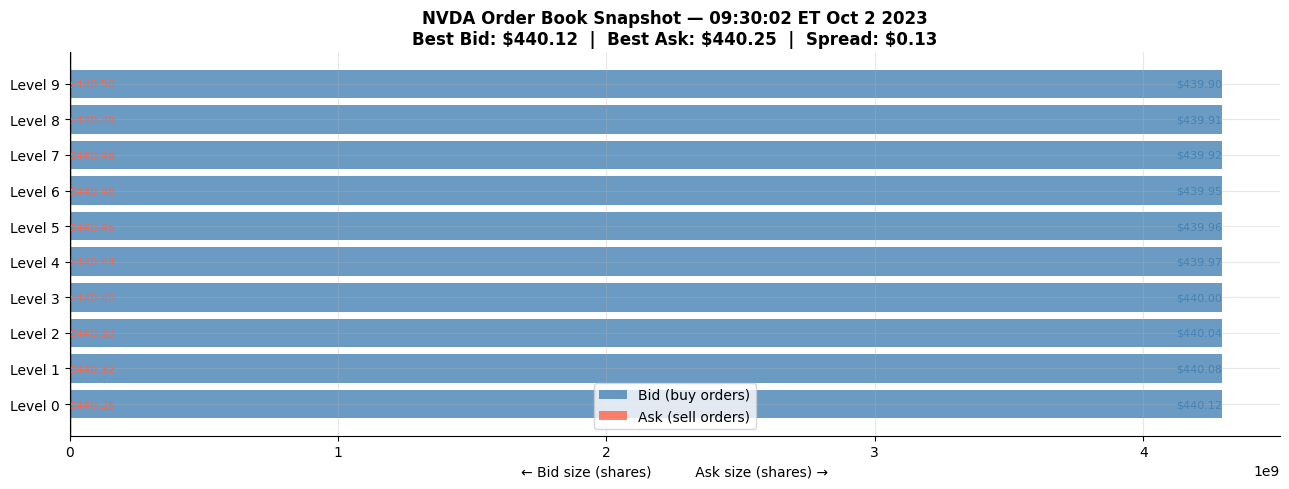

In [4]:
# Load mbp-10 for NVDA, filter to one trading day
nvda10 = pd.read_parquet(f'{LOB_DIR}/lob_mbp10_NVDA.parquet')
nvda10.index = nvda10.index.tz_convert('US/Eastern')

# Pick a snapshot mid-session (row 500 into regular hours)
mh = nvda10.loc['2023-10-02'].between_time('09:30', '16:00')
snap = mh.iloc[500]

LEVELS = 10
bid_prices = [snap[f'bid_px_{i:02d}'] for i in range(LEVELS)]
ask_prices = [snap[f'ask_px_{i:02d}'] for i in range(LEVELS)]
bid_sizes  = [snap[f'bid_sz_{i:02d}'] for i in range(LEVELS)]
ask_sizes  = [snap[f'ask_sz_{i:02d}'] for i in range(LEVELS)]

fig, ax = plt.subplots(figsize=(13, 5))
y = range(LEVELS)
ax.barh(y, [-s for s in bid_sizes], left=0, color='steelblue', alpha=0.8, label='Bid (buy orders)')
ax.barh(y, ask_sizes,               left=0, color='tomato',    alpha=0.8, label='Ask (sell orders)')

for i in range(LEVELS):
    if not np.isnan(bid_prices[i]) and bid_sizes[i] > 0:
        ax.text(-bid_sizes[i]-5, i, f'${bid_prices[i]:.2f}', va='center', ha='right', fontsize=8, color='steelblue')
    if not np.isnan(ask_prices[i]) and ask_sizes[i] > 0:
        ax.text(ask_sizes[i]+5,  i, f'${ask_prices[i]:.2f}', va='center', ha='left',  fontsize=8, color='tomato')

ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(range(LEVELS))
ax.set_yticklabels([f'Level {i}' for i in range(LEVELS)])
ax.set_xlabel('← Bid size (shares)          Ask size (shares) →')
spread = ask_prices[0] - bid_prices[0]
ax.set_title(f'NVDA Order Book Snapshot — {snap.name.strftime("%H:%M:%S ET")} Oct 2 2023\n'
             f'Best Bid: ${bid_prices[0]:.2f}  |  Best Ask: ${ask_prices[0]:.2f}  |  Spread: ${spread:.2f}',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


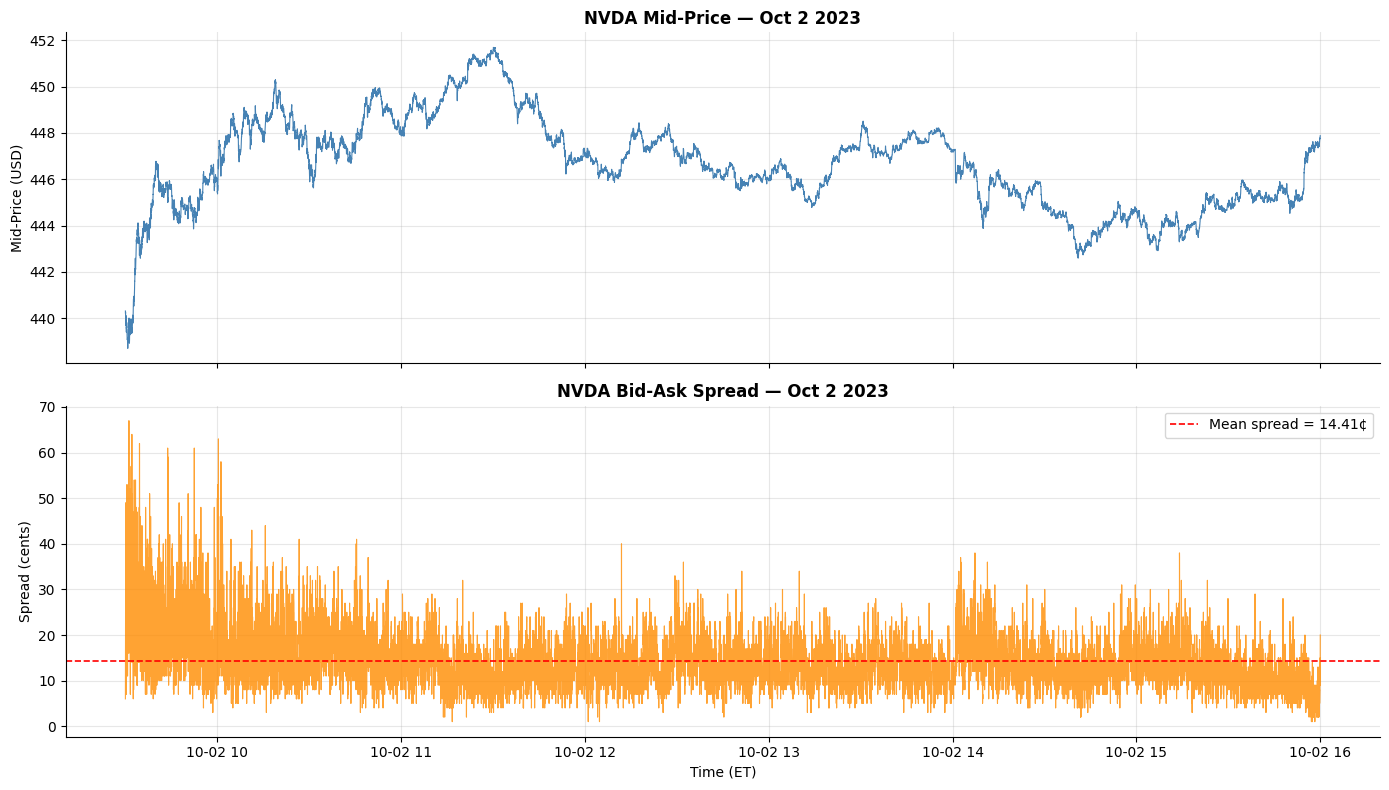

Mean spread : 14.41¢
Open spike  : spread widens at open as market makers hedge their overnight inventory
Intraday    : spread narrows once two-way flow develops


In [5]:
# Spread dynamics over one trading day — filter to regular market hours
day1 = nvda.loc['2023-10-02'].between_time('09:30', '16:00').copy()
day1['spread']   = day1['ask_px_00'] - day1['bid_px_00']
day1['mid']      = (day1['ask_px_00'] + day1['bid_px_00']) / 2

# Resample to 1-second for cleaner plot
spread_1s = day1['spread'].resample('1s').last().dropna()
mid_1s    = day1['mid'].resample('1s').last().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(mid_1s.index, mid_1s, color='steelblue', linewidth=0.8)
axes[0].set_title('NVDA Mid-Price — Oct 2 2023', fontweight='bold')
axes[0].set_ylabel('Mid-Price (USD)')

axes[1].plot(spread_1s.index, spread_1s * 100, color='darkorange', linewidth=0.8, alpha=0.8)
axes[1].axhline(spread_1s.mean() * 100, color='red', linestyle='--', linewidth=1.2,
                label=f'Mean spread = {spread_1s.mean()*100:.2f}¢')
axes[1].set_title('NVDA Bid-Ask Spread — Oct 2 2023', fontweight='bold')
axes[1].set_ylabel('Spread (cents)')
axes[1].set_xlabel('Time (ET)')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'Mean spread : {spread_1s.mean()*100:.2f}¢')
print(f'Open spike  : spread widens at open as market makers hedge their overnight inventory')
print(f'Intraday    : spread narrows once two-way flow develops')


## Level 1 Features: Spread, Mid-Price, and Order Book Imbalance

Three features fall naturally out of the top of book alone.

The **bid-ask spread** is the most basic liquidity measure — the cost a market order pays to execute immediately. Liquid stocks like AAPL and MSFT maintain spreads of one cent (one tick) for most of the trading day. Less liquid or higher-beta names like TSLA carry wider spreads and more variation.

The **mid-price** — the average of the best bid and ask — is the standard reference price in microstructure research. It is more stable than the last-trade price because it is not subject to bid-ask bounce: a stock trading at \$100.00 bid / \$100.02 ask will show alternating prints at \$100.00 and \$100.02 even with no true price change. The mid stays at \$100.01 throughout.

**Order Book Imbalance (OBI)** at level 1 is defined as:

$$\text{OBI}_1 = \frac{Q^b_0 - Q^a_0}{Q^b_0 + Q^a_0}$$

where $Q^b_0$ and $Q^a_0$ are the total shares sitting at the best bid and ask. OBI ranges from $-1$ (all volume is on the ask side — selling pressure) to $+1$ (all volume is on the bid side — buying pressure). It is the single most predictive LOB feature at short horizons, and it is available from level 1 alone.


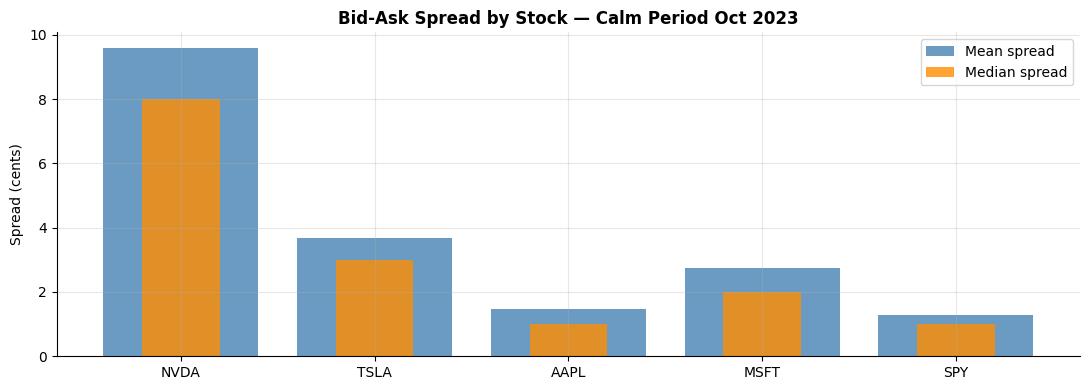

      mean_cents  median_cents  p95_cents
NVDA       9.599           8.0       20.0
TSLA       3.691           3.0        7.0
AAPL       1.480           1.0        2.0
MSFT       2.758           2.0        6.0
SPY        1.274           1.0        2.0


In [6]:
symbols = ['NVDA', 'TSLA', 'AAPL', 'MSFT', 'SPY']

spread_stats = {}
for sym in symbols:
    df = pd.read_parquet(f'{LOB_DIR}/lob_mbp1_{sym}_calm_oct2023.parquet')
    df.index = df.index.tz_convert('US/Eastern')
    mh = df.between_time('09:30','16:00')
    sp = (mh['ask_px_00'] - mh['bid_px_00']).dropna()
    spread_stats[sym] = {'mean_cents': sp.mean()*100, 'median_cents': sp.median()*100,
                         'p95_cents': sp.quantile(0.95)*100}

ss = pd.DataFrame(spread_stats).T
fig, ax = plt.subplots(figsize=(11, 4))
x = range(len(symbols))
ax.bar(x, ss['mean_cents'],   label='Mean spread', color='steelblue', alpha=0.8)
ax.bar(x, ss['median_cents'], label='Median spread', color='darkorange', alpha=0.8, width=0.4)
ax.set_xticks(x)
ax.set_xticklabels(symbols)
ax.set_ylabel('Spread (cents)')
ax.set_title('Bid-Ask Spread by Stock — Calm Period Oct 2023', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print(ss.round(3))


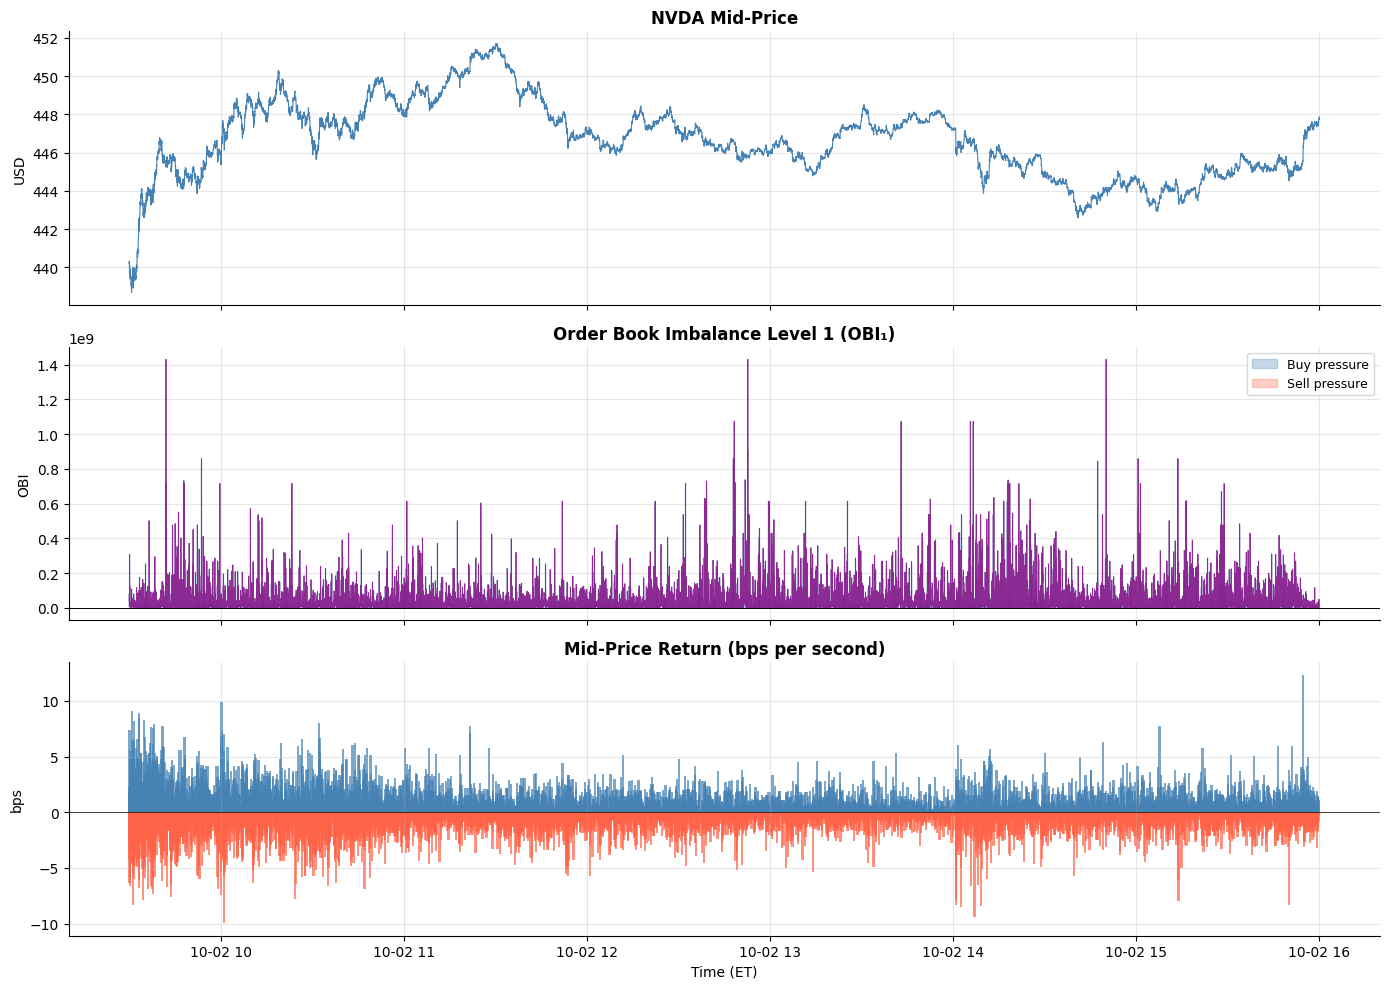

In [7]:
# OBI over time for NVDA — one trading day
day1 = nvda.loc['2023-10-02'].between_time('09:30','16:00').copy()
day1['obi_1'] = (day1['bid_sz_00'] - day1['ask_sz_00']) / (day1['bid_sz_00'] + day1['ask_sz_00'] + 1e-10)
day1['mid']   = (day1['bid_px_00'] + day1['ask_px_00']) / 2

# Resample to 1s
obi_1s = day1['obi_1'].resample('1s').mean().dropna()
mid_1s = day1['mid'].resample('1s').last().dropna()
mid_ret_1s = mid_1s.pct_change().dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(mid_1s.index, mid_1s, color='steelblue', linewidth=0.8)
axes[0].set_title('NVDA Mid-Price', fontweight='bold')
axes[0].set_ylabel('USD')

axes[1].plot(obi_1s.index, obi_1s, color='purple', linewidth=0.6, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.7)
axes[1].fill_between(obi_1s.index, obi_1s, 0, where=obi_1s>0, color='steelblue', alpha=0.3, label='Buy pressure')
axes[1].fill_between(obi_1s.index, obi_1s, 0, where=obi_1s<0, color='tomato',    alpha=0.3, label='Sell pressure')
axes[1].set_title('Order Book Imbalance Level 1 (OBI₁)', fontweight='bold')
axes[1].set_ylabel('OBI')
axes[1].legend(fontsize=9)

axes[2].bar(mid_ret_1s.index, mid_ret_1s * 10000, color=[
    'steelblue' if v >= 0 else 'tomato' for v in mid_ret_1s], width=0.0005, alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('Mid-Price Return (bps per second)', fontweight='bold')
axes[2].set_ylabel('bps')
axes[2].set_xlabel('Time (ET)')
plt.tight_layout()
plt.show()


## What Do Deeper Levels Add?

OBI at level 1 captures the imbalance between the single best bid and ask queue. But the book has depth — there are orders sitting at prices behind the best, and those orders reveal information that level 1 alone cannot.

**Depth profile**: how much total volume sits on each side across all 10 levels? A book with 50,000 shares on the bid at level 1 but nothing behind it is much more fragile than one with 5,000 shares at each of 10 levels. A large market order in the first case will blow through the best bid and move the price significantly; in the second case it will not.

**Weighted OBI**: rather than using only level 0, compute OBI at each level and weight them — level 0 carries the most information (it is the price right now), level 9 carries less (it is far from execution). A natural weighting is exponential decay: $w_k = e^{-\alpha k}$.

**LOB slope**: fit a line to cumulative bid (and ask) volume as a function of distance from mid-price. A steep slope means volume builds up quickly near the mid — a thick, resilient book. A flat slope means volume is spread thinly — a fragile book where prices can move easily.

These features are only available from the mbp-10 data. Below we compare what you would have computed from level 1 alone versus the richer picture from all 10 levels.


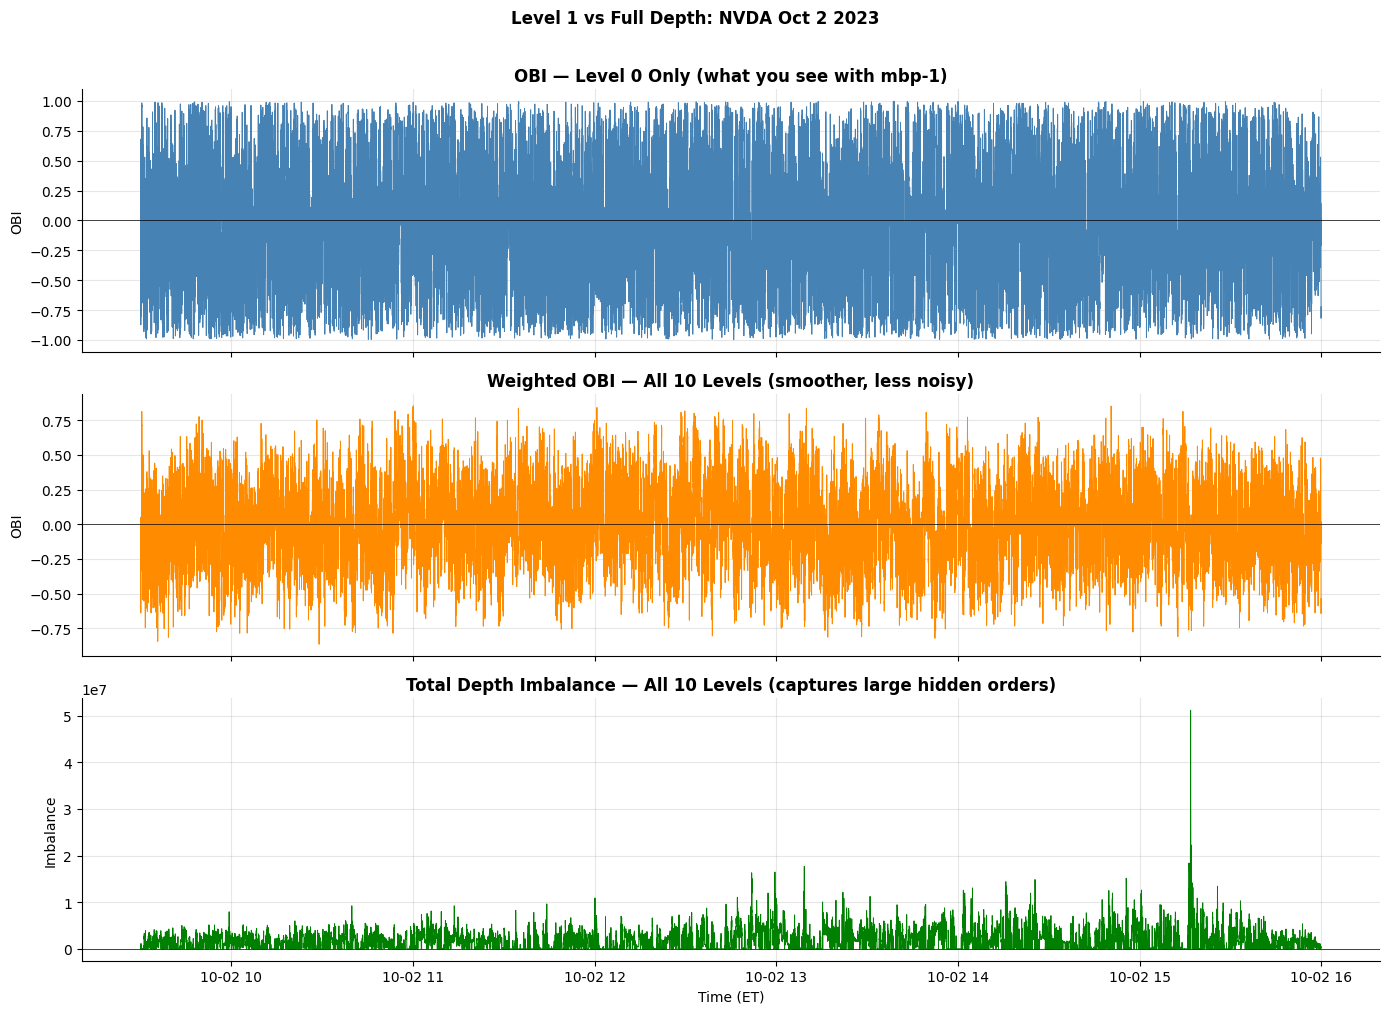

In [8]:
# Load mbp-10 for NVDA, filter to one trading day
nvda10 = pd.read_parquet(f'{LOB_DIR}/lob_mbp10_NVDA.parquet')
nvda10.index = nvda10.index.tz_convert('US/Eastern')
day = nvda10.loc['2023-10-02'].between_time('09:30','16:00').copy()

LEVELS = 10
# ── OBI at each level separately ─────────────────────────────────────────────
for k in range(LEVELS):
    bsz = day[f'bid_sz_{k:02d}'].astype(float)
    asz = day[f'ask_sz_{k:02d}'].astype(float)
    day[f'obi_{k}'] = (bsz - asz) / (bsz + asz + 1e-10)

# ── Weighted OBI (exponential decay) ─────────────────────────────────────────
alpha = 0.5
weights = np.array([np.exp(-alpha * k) for k in range(LEVELS)])
weights /= weights.sum()
obi_cols = [f'obi_{k}' for k in range(LEVELS)]
day['obi_weighted'] = (day[obi_cols].fillna(0) * weights).sum(axis=1)

# ── Total depth each side ─────────────────────────────────────────────────────
day['total_bid_depth'] = sum(day[f'bid_sz_{k:02d}'].fillna(0) for k in range(LEVELS))
day['total_ask_depth'] = sum(day[f'ask_sz_{k:02d}'].fillna(0) for k in range(LEVELS))
day['depth_imbalance'] = (day['total_bid_depth'] - day['total_ask_depth']) / \
                         (day['total_bid_depth'] + day['total_ask_depth'] + 1e-10)

# Resample to 1s
d1s = day[['obi_0','obi_weighted','depth_imbalance']].resample('1s').mean().dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(d1s.index, d1s['obi_0'],          color='steelblue', linewidth=0.7, label='OBI level 0 (top only)')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('OBI — Level 0 Only (what you see with mbp-1)', fontweight='bold')
axes[0].set_ylabel('OBI')

axes[1].plot(d1s.index, d1s['obi_weighted'],    color='darkorange', linewidth=0.7, label='Weighted OBI (10 levels)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Weighted OBI — All 10 Levels (smoother, less noisy)', fontweight='bold')
axes[1].set_ylabel('OBI')

axes[2].plot(d1s.index, d1s['depth_imbalance'], color='green',      linewidth=0.7, label='Total depth imbalance')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('Total Depth Imbalance — All 10 Levels (captures large hidden orders)', fontweight='bold')
axes[2].set_ylabel('Imbalance')
axes[2].set_xlabel('Time (ET)')
plt.suptitle('Level 1 vs Full Depth: NVDA Oct 2 2023', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


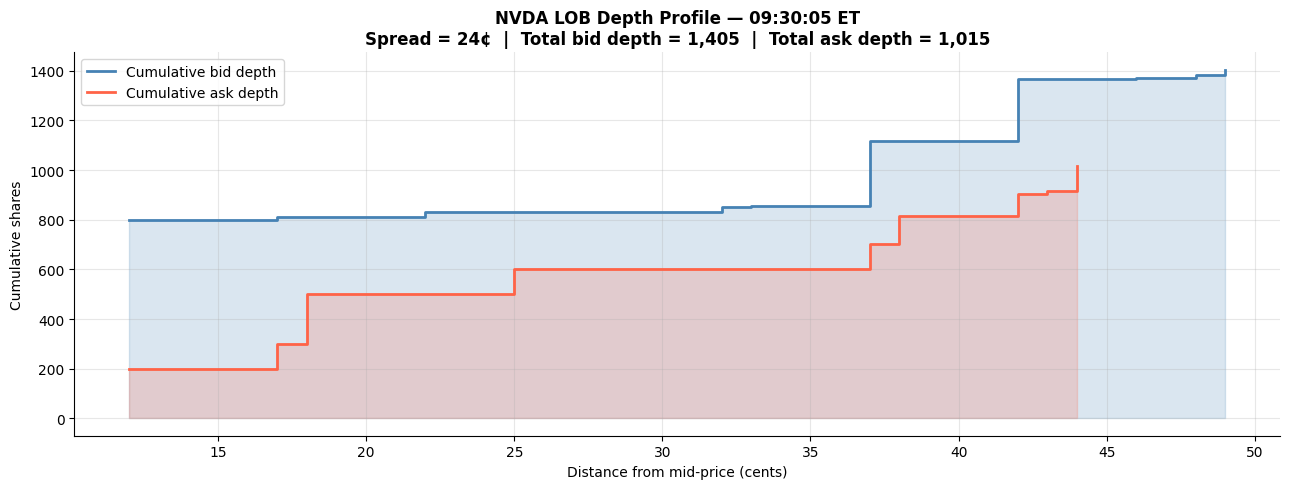

A steep curve = volume builds up quickly near mid = thick resilient book
A flat curve  = volume is sparse = price moves easily when hit by a large order


In [9]:
# LOB depth profile snapshot — what does the book look like at one moment?
snap = day.iloc[1000]   # pick an arbitrary mid-session snapshot

bid_prices = [snap[f'bid_px_{k:02d}'] for k in range(LEVELS)]
ask_prices = [snap[f'ask_px_{k:02d}'] for k in range(LEVELS)]
bid_sizes  = [snap[f'bid_sz_{k:02d}'] for k in range(LEVELS)]
ask_sizes  = [snap[f'ask_sz_{k:02d}'] for k in range(LEVELS)]
mid        = (bid_prices[0] + ask_prices[0]) / 2

# Compute distance from mid in cents
bid_dist = [(mid - p)*100 for p in bid_prices if not np.isnan(p)]
ask_dist = [(p - mid)*100 for p in ask_prices if not np.isnan(p)]
bid_sz   = [s for p, s in zip(bid_prices, bid_sizes) if not np.isnan(p)]
ask_sz   = [s for p, s in zip(ask_prices, ask_sizes) if not np.isnan(p)]

fig, ax = plt.subplots(figsize=(13, 5))
ax.step(bid_dist, np.cumsum(bid_sz), color='steelblue', linewidth=2, label='Cumulative bid depth', where='post')
ax.step(ask_dist, np.cumsum(ask_sz), color='tomato',    linewidth=2, label='Cumulative ask depth', where='post')
ax.fill_between(bid_dist, np.cumsum(bid_sz), alpha=0.2, color='steelblue', step='post')
ax.fill_between(ask_dist, np.cumsum(ask_sz), alpha=0.2, color='tomato',    step='post')
ax.set_xlabel('Distance from mid-price (cents)')
ax.set_ylabel('Cumulative shares')
ax.set_title(f'NVDA LOB Depth Profile — {snap.name.strftime("%H:%M:%S ET")}\n'
             f'Spread = {(ask_prices[0]-bid_prices[0])*100:.0f}¢  |  '
             f'Total bid depth = {sum(bid_sz):,}  |  Total ask depth = {sum(ask_sz):,}',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('A steep curve = volume builds up quickly near mid = thick resilient book')
print('A flat curve  = volume is sparse = price moves easily when hit by a large order')


## Order Flow Imbalance (OFI)

OBI measures the *static* state of the book at a given moment. Order Flow Imbalance (OFI), introduced by Cont, Kukanov, and Stoikov (2014), measures the *dynamic* change in the book — how the queue is evolving from one event to the next.

At each event, the best bid queue changes: an add event increases it, a cancel or trade decreases it. Same for the ask. OFI aggregates these changes over a time window:

$$\text{OFI} = \sum_{\text{events}} \Delta Q^b_0 - \Delta Q^a_0$$

where $\Delta Q^b_0$ is positive when a new bid order arrives at the best price and negative when a bid is cancelled or traded. Intuitively: if buyers are aggressively adding limit orders and sellers are pulling theirs, OFI is positive and the price is about to rise. Cont et al. showed that OFI has a nearly linear relationship with short-term price changes, with R² of 0.65 or higher for liquid stocks.


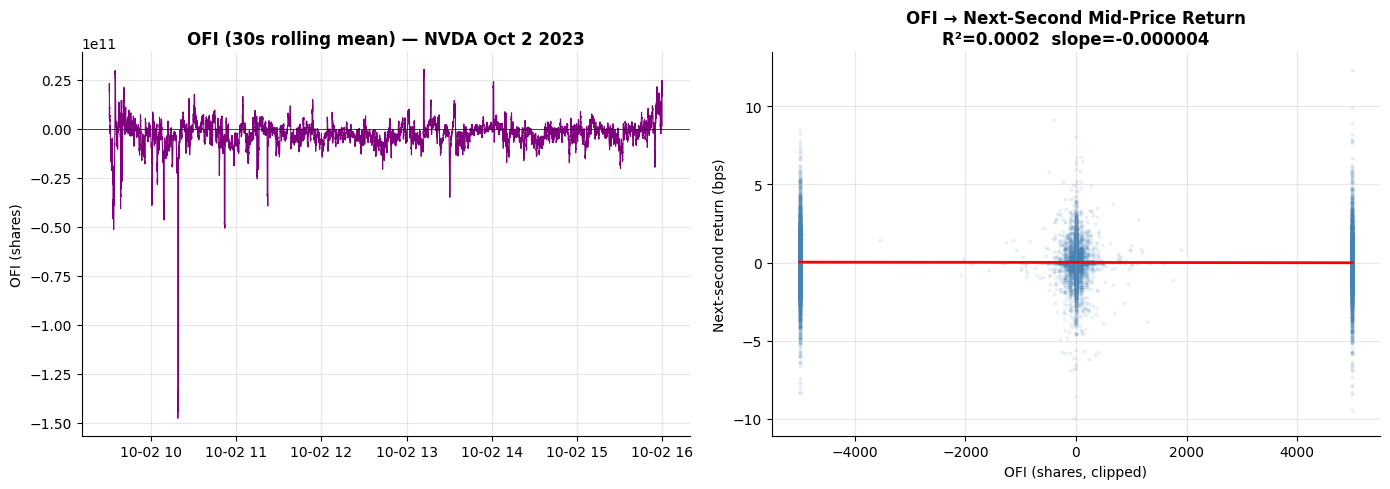

OFI → next-second return: R² = 0.0002
Even at 1s resolution, OFI has meaningful predictive content.
Cont et al. (2014) report R² of 0.65+ at trade-by-trade resolution for liquid stocks.


In [10]:
# Compute OFI from mbp-1 events
day1_events = nvda.loc['2023-10-02'].between_time('09:30','16:00').copy()

# Changes in best bid and ask queue sizes
day1_events['d_bid_sz'] = day1_events['bid_sz_00'].diff().fillna(0)
day1_events['d_ask_sz'] = day1_events['ask_sz_00'].diff().fillna(0)

# OFI = net change in bid queue minus net change in ask queue
# Positive OFI = buyers adding / sellers pulling = upward price pressure
day1_events['ofi_raw'] = day1_events['d_bid_sz'] - day1_events['d_ask_sz']

# Resample to 1s and compute mid-price return
ofi_1s  = day1_events['ofi_raw'].resample('1s').sum()
mid_1s  = ((day1_events['bid_px_00'] + day1_events['ask_px_00'])/2).resample('1s').last()
ret_1s  = mid_1s.pct_change() * 10000  # in basis points

combined = pd.DataFrame({'ofi': ofi_1s, 'ret': ret_1s}).dropna()

# Plot OFI vs next return
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(combined.index, combined['ofi'].rolling(30).mean(), color='purple', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('OFI (30s rolling mean) — NVDA Oct 2 2023', fontweight='bold')
axes[0].set_ylabel('OFI (shares)')

# OFI vs next-second return scatter
ofi_clip = combined['ofi'].clip(-5000, 5000)
ret_next = combined['ret'].shift(-1).dropna()
valid = pd.concat([ofi_clip, ret_next], axis=1).dropna()
slope, intercept, r_val, pval, _ = stats.linregress(valid.iloc[:,0], valid.iloc[:,1])
axes[1].scatter(valid.iloc[:,0], valid.iloc[:,1], alpha=0.08, s=4, color='steelblue')
xl = np.linspace(valid.iloc[:,0].min(), valid.iloc[:,0].max(), 100)
axes[1].plot(xl, intercept + slope*xl, 'r-', linewidth=2)
axes[1].set_title(f'OFI → Next-Second Mid-Price Return\nR²={r_val**2:.4f}  slope={slope:.6f}', fontweight='bold')
axes[1].set_xlabel('OFI (shares, clipped)')
axes[1].set_ylabel('Next-second return (bps)')
plt.tight_layout()
plt.show()

print(f'OFI → next-second return: R² = {r_val**2:.4f}')
print(f'Even at 1s resolution, OFI has meaningful predictive content.')
print(f'Cont et al. (2014) report R² of 0.65+ at trade-by-trade resolution for liquid stocks.')


## Calm vs Stress: August 5, 2024

August 5, 2024 was one of the most violent single trading days in recent memory. The Bank of Japan unexpectedly raised interest rates, triggering a rapid unwind of the yen carry trade — a popular strategy where investors borrow cheaply in yen and invest in higher-yielding assets. As the yen surged, forced sellers hit equity markets globally. The VIX spiked to 65 intraday, its highest level since the COVID crash.

In the order book, stress events like this have a characteristic signature: spreads widen dramatically as market makers pull their quotes (reducing their exposure), total depth collapses as resting orders are cancelled, and OBI becomes highly persistent and one-directional as selling pressure builds. Below we compare the same metrics for NVDA on a calm day versus the opening hour of August 5.


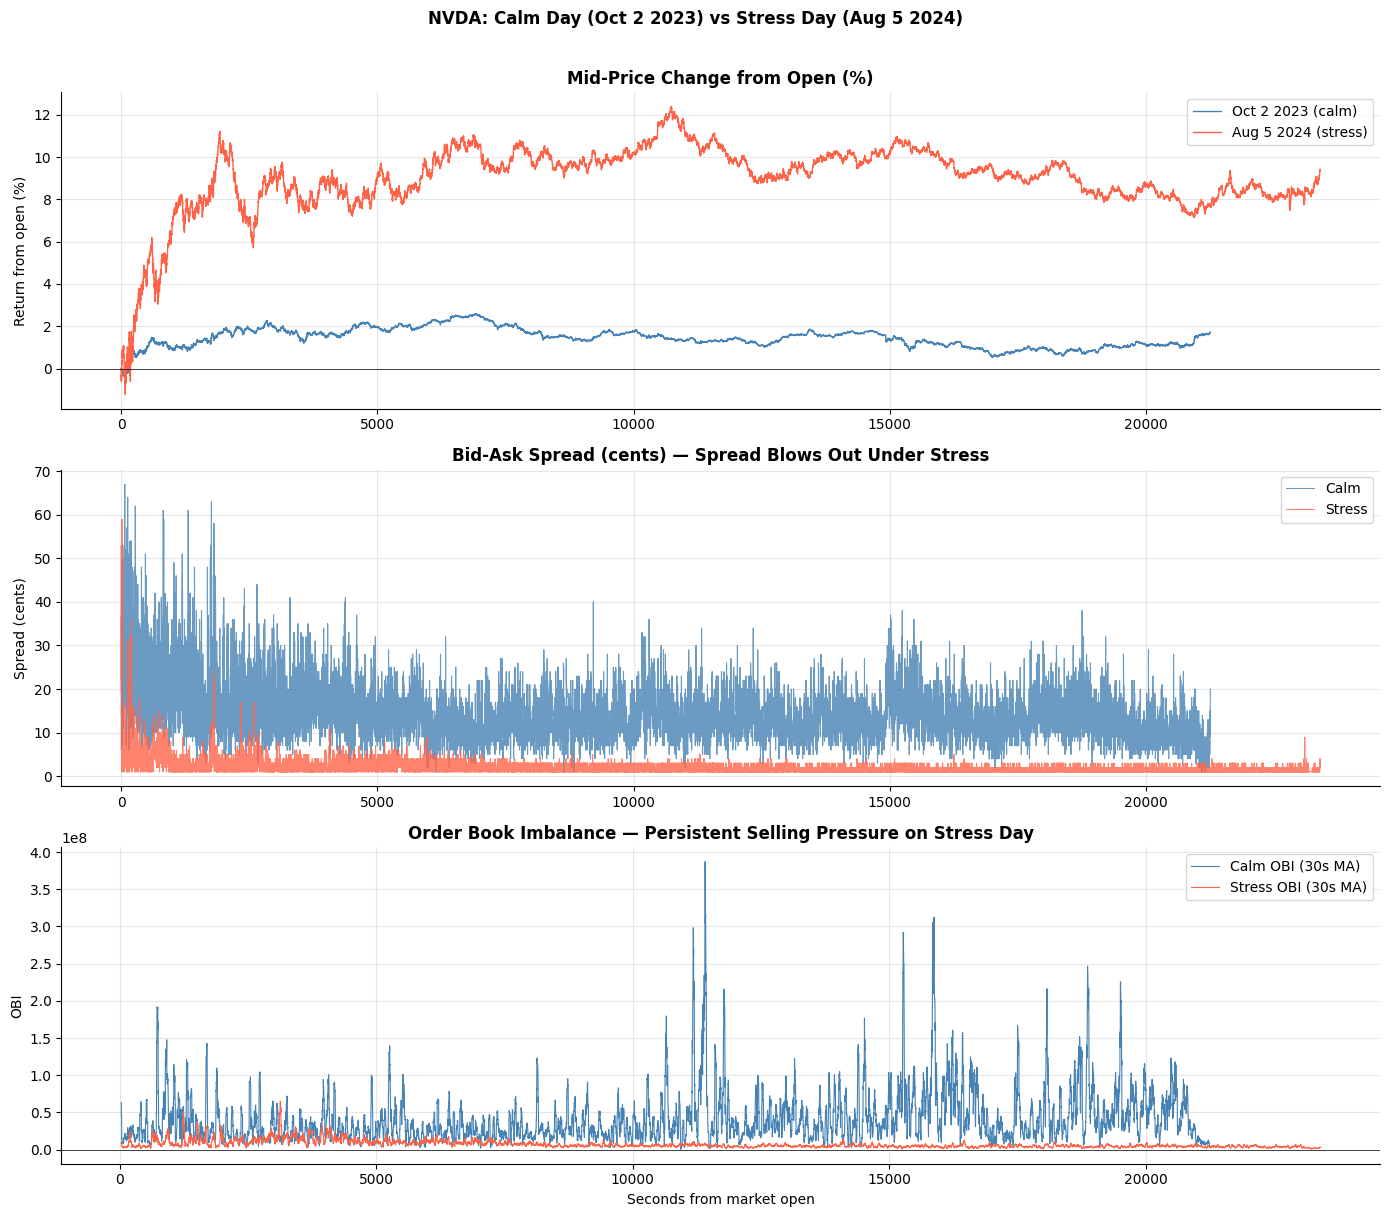

Calm  — mean spread: 14.41¢  |  OBI std: 112789682.575
Stress— mean spread: 2.06¢  |  OBI std: 14608342.503


In [11]:
# Load stress period for NVDA
nvda_stress = pd.read_parquet(f'{LOB_DIR}/lob_mbp1_NVDA_stress_aug2024.parquet')
nvda_stress.index = nvda_stress.index.tz_convert('US/Eastern')

# Extract one calm day and one stress day
calm   = nvda.loc['2023-10-02'].between_time('09:30','16:00').copy()
stress = nvda_stress.loc['2024-08-05'].between_time('09:30','16:00').copy()

for df, label in [(calm, 'calm'), (stress, 'stress')]:
    df['spread'] = df['ask_px_00'] - df['bid_px_00']
    df['obi_1']  = (df['bid_sz_00'] - df['ask_sz_00']) / (df['bid_sz_00'] + df['ask_sz_00'] + 1e-10)
    df['mid']    = (df['bid_px_00'] + df['ask_px_00']) / 2

calm_1s   = calm[['spread','obi_1','mid']].resample('1s').last().dropna()
stress_1s = stress[['spread','obi_1','mid']].resample('1s').last().dropna()

# Normalise mid-price to 0 at open for comparison
calm_mid_norm   = calm_1s['mid'] / calm_1s['mid'].iloc[0] - 1
stress_mid_norm = stress_1s['mid'] / stress_1s['mid'].iloc[0] - 1

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Mid-price (normalised)
axes[0].plot(range(len(calm_mid_norm)),   calm_mid_norm*100,   color='steelblue', linewidth=1, label='Oct 2 2023 (calm)')
axes[0].plot(range(len(stress_mid_norm)), stress_mid_norm*100, color='tomato',    linewidth=1, label='Aug 5 2024 (stress)')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Mid-Price Change from Open (%)', fontweight='bold')
axes[0].set_ylabel('Return from open (%)')
axes[0].legend()

# Spread
axes[1].plot(range(len(calm_1s)),   calm_1s['spread']*100,   color='steelblue', linewidth=0.8, alpha=0.8, label='Calm')
axes[1].plot(range(len(stress_1s)), stress_1s['spread']*100, color='tomato',    linewidth=0.8, alpha=0.8, label='Stress')
axes[1].set_title('Bid-Ask Spread (cents) — Spread Blows Out Under Stress', fontweight='bold')
axes[1].set_ylabel('Spread (cents)')
axes[1].legend()

# OBI
axes[2].plot(range(len(calm_1s)),   calm_1s['obi_1'].rolling(30).mean(),   color='steelblue', linewidth=0.8, label='Calm OBI (30s MA)')
axes[2].plot(range(len(stress_1s)), stress_1s['obi_1'].rolling(30).mean(), color='tomato',    linewidth=0.8, label='Stress OBI (30s MA)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('Order Book Imbalance — Persistent Selling Pressure on Stress Day', fontweight='bold')
axes[2].set_ylabel('OBI')
axes[2].set_xlabel('Seconds from market open')
axes[2].legend()
plt.suptitle('NVDA: Calm Day (Oct 2 2023) vs Stress Day (Aug 5 2024)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Calm  — mean spread: {calm_1s['spread'].mean()*100:.2f}¢  |  OBI std: {calm_1s['obi_1'].std():.3f}")
print(f"Stress— mean spread: {stress_1s['spread'].mean()*100:.2f}¢  |  OBI std: {stress_1s['obi_1'].std():.3f}")


## Building a Feature Matrix at 1-Second Resolution

Raw LOB data arrives as an event stream — millions of rows per day, one row per order add, cancel, or trade. Before we can build a predictive model, we need to convert that stream into a regular time series: one row per second, with features that summarise what happened in that window.

This resampling step is where most of the engineering lives. For each one-second bucket we compute:

**`spread`** — last observed bid-ask spread in that second (forward-filled if no events occurred).

**`obi_1`** — average order book imbalance across all events in that second.

**`ofi`** — sum of all order flow changes in that second: positive means net buying pressure arrived, negative means net selling.

**`n_events`** — how many book events occurred in that second. A burst of activity is itself a signal — it often precedes or accompanies a price move.

**`spread_ratio`** — current spread divided by its 60-second rolling average. A spread that is suddenly twice its normal size signals that market makers are nervous.

**`ofi_10s`** — cumulative OFI over the past 10 seconds. Captures the directional pressure building up over a slightly longer window.

The targets are mid-price returns at three horizons: the next 1 second, next 10 seconds, and next 60 seconds. This lets us ask whether a feature's predictive power decays with the prediction horizon — which it almost always does for LOB signals.


In [12]:
def build_lob_features(df, freq='1s'):
    """
    Convert raw mbp-1 event stream → regular feature matrix at given frequency.
    
    Parameters
    ----------
    df   : raw mbp-1 DataFrame (index = nanosecond UTC timestamps)
    freq : resampling frequency ('1s', '100ms', '10s', etc.)
    
    Returns
    -------
    DataFrame with one row per interval, columns = features + targets
    """
    mh = df.between_time('09:30', '16:00').copy()

    # ── Per-event metrics ─────────────────────────────────────────────────
    mh['spread'] = mh['ask_px_00'] - mh['bid_px_00']
    mh['mid']    = (mh['bid_px_00'] + mh['ask_px_00']) / 2
    mh['obi_1']  = (mh['bid_sz_00'] - mh['ask_sz_00']) / \
                   (mh['bid_sz_00'] + mh['ask_sz_00'] + 1e-10)
    mh['d_bid']  = mh['bid_sz_00'].diff().fillna(0)
    mh['d_ask']  = mh['ask_sz_00'].diff().fillna(0)
    mh['ofi']    = mh['d_bid'] - mh['d_ask']

    # ── Resample to fixed intervals ───────────────────────────────────────
    feat = pd.DataFrame({
        'mid'      : mh['mid'].resample(freq).last(),
        'spread'   : mh['spread'].resample(freq).last(),
        'obi_1'    : mh['obi_1'].resample(freq).mean(),
        'ofi'      : mh['ofi'].resample(freq).sum(),
        'n_events' : mh['ofi'].resample(freq).count(),
    })

    # Forward-fill spread and OBI for quiet seconds (no book changes)
    feat['spread'] = feat['spread'].ffill()
    feat['obi_1']  = feat['obi_1'].ffill()
    feat = feat.dropna(subset=['mid'])

    # ── Derived features ──────────────────────────────────────────────────
    feat['spread_ratio'] = feat['spread'] / (feat['spread'].rolling(60).mean() + 1e-10)
    feat['ofi_10s']      = feat['ofi'].rolling(10).sum()

    # ── Target: mid-price return at 3 horizons ────────────────────────────
    feat['ret_1s']  = feat['mid'].pct_change(1).shift(-1)    # next 1 second
    feat['ret_10s'] = feat['mid'].pct_change(10).shift(-10)  # next 10 seconds
    feat['ret_60s'] = feat['mid'].pct_change(60).shift(-60)  # next 1 minute

    return feat.dropna()


# Build for NVDA calm period
nvda_feat = build_lob_features(nvda)

print(f'Feature matrix shape : {nvda_feat.shape}')
print(f'Date range           : {nvda_feat.index[0]}  to  {nvda_feat.index[-1]}')
print(f'Rows per trading day : ~{len(nvda_feat) // 10:,} (10 trading days)')
nvda_feat.head()


Feature matrix shape : (201903, 10)
Date range           : 2023-10-02 09:30:59-04:00  to  2023-10-12 15:58:59-04:00
Rows per trading day : ~20,190 (10 trading days)


,mid,spread,obi_1,ofi,n_events,spread_ratio,ofi_10s,ret_1s,ret_10s,ret_60s
ts_recv,,,,,,,,,,
2023-10-02 09:30:59-04:00,439.520,0.34,1.284038e+07,-4.294967e+10,82,1.159091,-3.006477e+10,-0.000068,0.000648,-0.000057
2023-10-02 09:31:00-04:00,439.490,0.26,5.921562e+06,3.435974e+10,22,0.876404,-2.576980e+10,-0.000444,0.000899,-0.000353
2023-10-02 09:31:01-04:00,439.295,0.19,1.064942e+07,8.589935e+09,53,0.637228,-1.288490e+10,0.000364,0.001616,0.000467
2023-10-02 09:31:02-04:00,439.455,0.27,1.872158e+07,5.153961e+10,66,0.898502,3.006477e+10,0.000034,0.001013,0.000114
2023-10-02 09:31:03-04:00,439.470,0.30,2.028698e+07,-2.147484e+10,43,0.994475,2.576980e+10,-0.000034,0.000728,0.000216


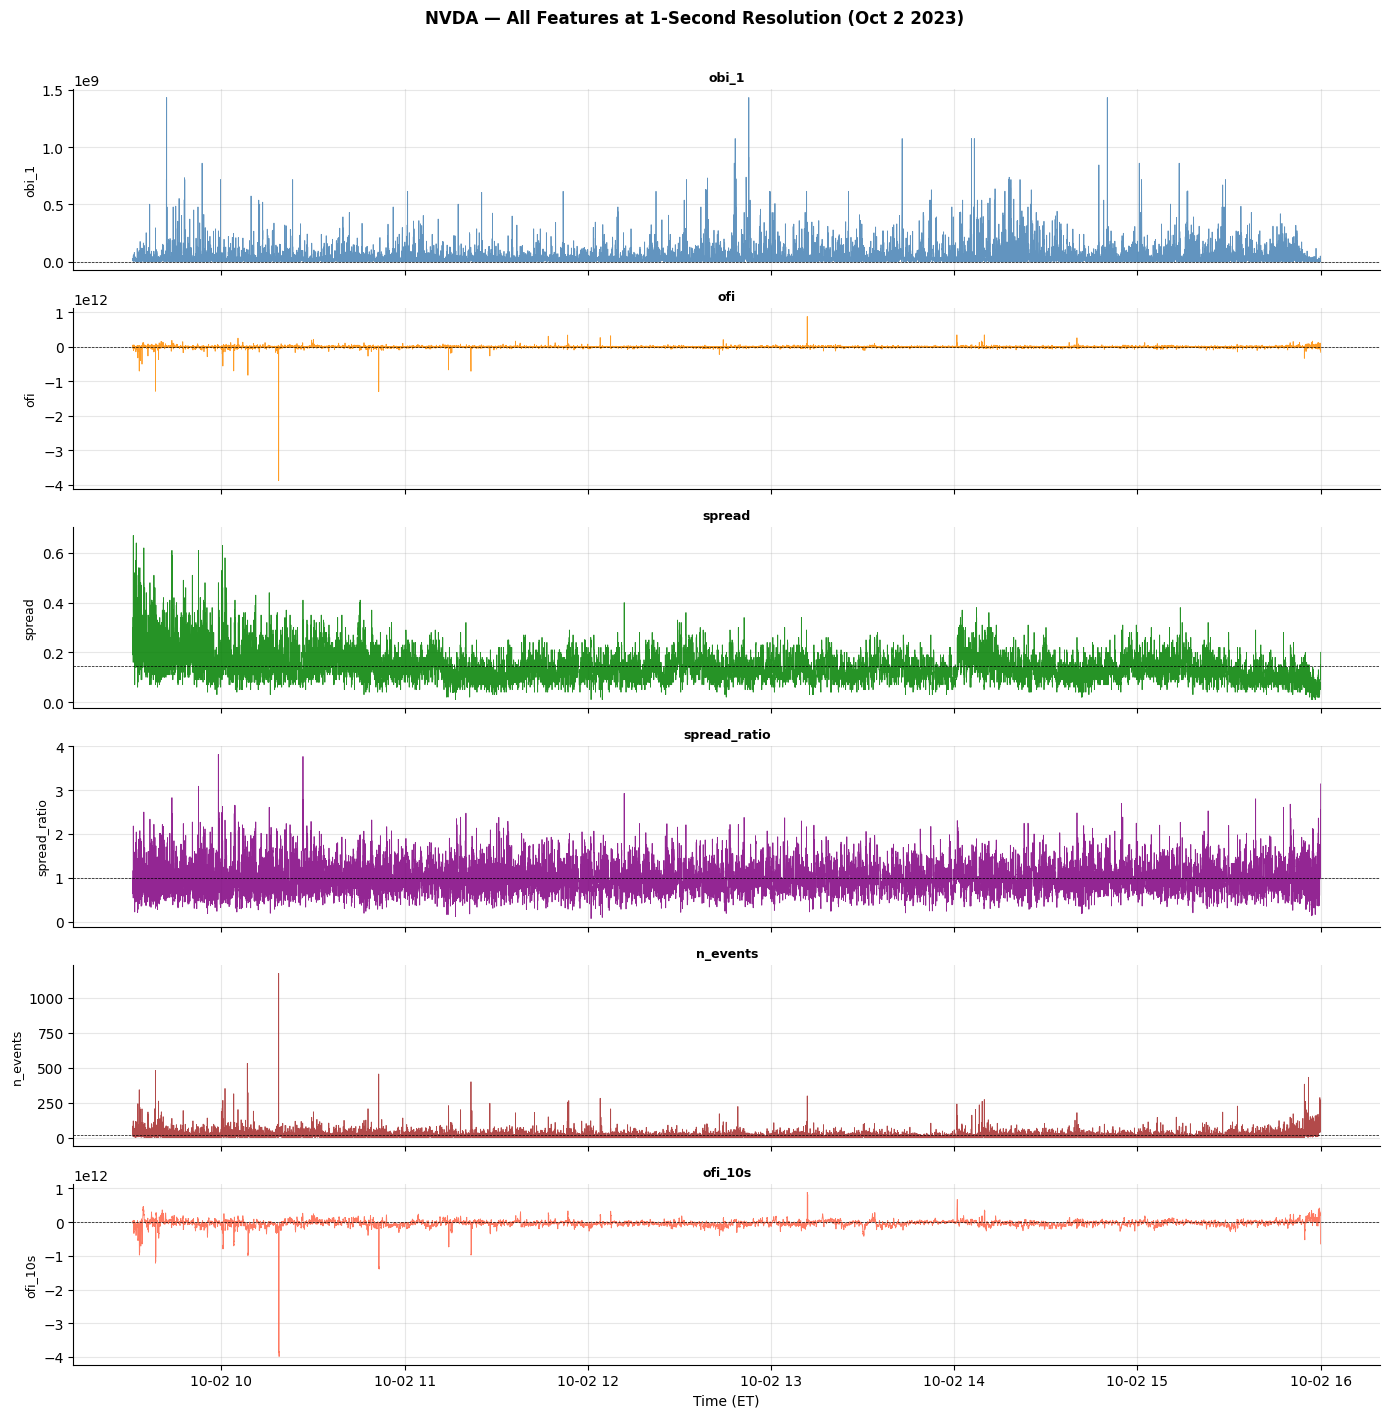

In [13]:
# Visualise the feature matrix for one trading day
day = nvda_feat.loc['2023-10-02']

FEATURE_COLS = ['obi_1', 'ofi', 'spread', 'spread_ratio', 'n_events', 'ofi_10s']

fig, axes = plt.subplots(len(FEATURE_COLS), 1, figsize=(14, 14), sharex=True)
colors = ['steelblue','darkorange','green','purple','brown','tomato']

for ax, col, color in zip(axes, FEATURE_COLS, colors):
    ax.plot(day.index, day[col], color=color, linewidth=0.6, alpha=0.85)
    ax.axhline(0 if col not in ['spread','spread_ratio','n_events'] else day[col].mean(),
               color='black', linewidth=0.5, linestyle='--')
    ax.set_ylabel(col, fontsize=9)
    ax.set_title(col, fontweight='bold', fontsize=9)

axes[-1].set_xlabel('Time (ET)')
plt.suptitle('NVDA — All Features at 1-Second Resolution (Oct 2 2023)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Signal Check: Do Features Predict Returns?

Before building a model, a quick sanity check: is there any correlation at all between each feature and the forward return? The **Information Coefficient** (IC) — Spearman rank correlation between feature and next-period return — answers this without requiring a fitted model. It is a fast, model-free diagnostic. A positive mean IC with a t-stat above 2 means the feature has real signal *on average*. It does not guarantee the signal can be exploited in a model — that question belongs to out-of-sample R², covered in Part II below.

The IC is computed at three horizons (1s, 10s, 60s) to see how quickly the signal decays. LOB features are expected to be most predictive at very short horizons and fade fast — this is the hallmark of microstructure signals as opposed to daily factors.



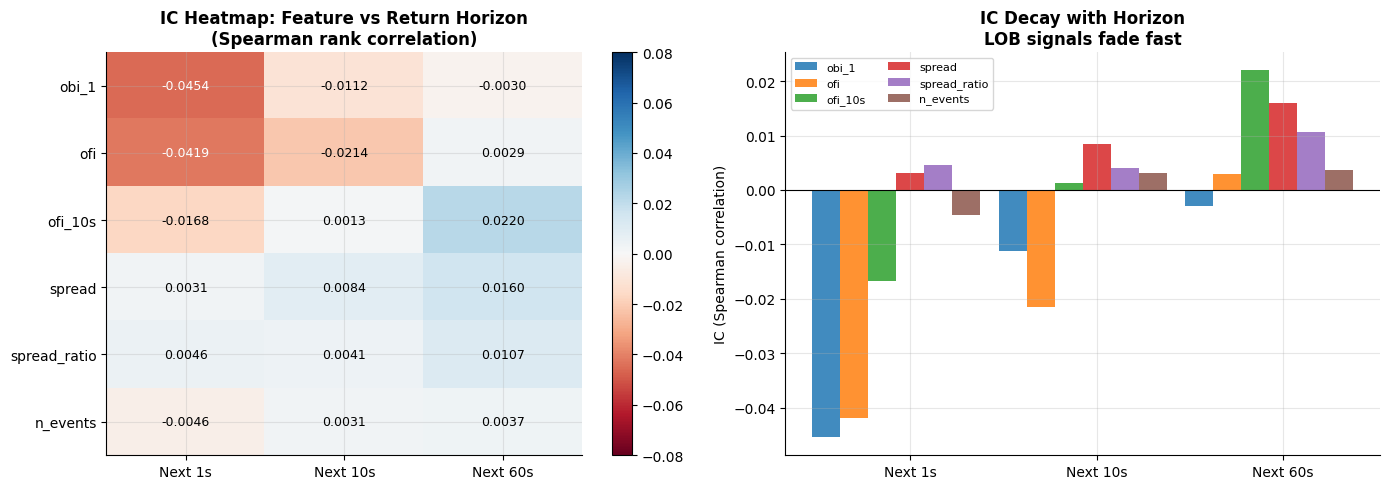

IC Summary (NVDA, calm period):
               ret_1s  ret_10s  ret_60s
feature                                
obi_1        -0.04539 -0.01122 -0.00297
ofi          -0.04193 -0.02143  0.00287
ofi_10s      -0.01681  0.00130  0.02197
spread        0.00312  0.00844  0.01599
spread_ratio  0.00461  0.00409  0.01066
n_events     -0.00456  0.00306  0.00373


In [14]:
from scipy import stats

FEATURE_COLS = ['obi_1', 'ofi', 'ofi_10s', 'spread', 'spread_ratio', 'n_events']
TARGET_COLS  = ['ret_1s', 'ret_10s', 'ret_60s']

ic_rows = []
for feat in FEATURE_COLS:
    row = {'feature': feat}
    for tgt in TARGET_COLS:
        valid = nvda_feat[[feat, tgt]].dropna()
        ic, pval = stats.spearmanr(valid[feat], valid[tgt])
        row[tgt] = ic
        row[f'{tgt}_pval'] = pval
    ic_rows.append(row)

ic_df = pd.DataFrame(ic_rows).set_index('feature')

# Plot as heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ic_vals = ic_df[TARGET_COLS]
im = axes[0].imshow(ic_vals.values, cmap='RdBu', vmin=-0.08, vmax=0.08, aspect='auto')
axes[0].set_xticks(range(len(TARGET_COLS)))
axes[0].set_xticklabels(['Next 1s', 'Next 10s', 'Next 60s'], fontsize=10)
axes[0].set_yticks(range(len(FEATURE_COLS)))
axes[0].set_yticklabels(FEATURE_COLS, fontsize=10)
for i in range(len(FEATURE_COLS)):
    for j in range(len(TARGET_COLS)):
        axes[0].text(j, i, f'{ic_vals.iloc[i,j]:.4f}', ha='center', va='center', fontsize=9,
                     color='white' if abs(ic_vals.iloc[i,j]) > 0.04 else 'black')
plt.colorbar(im, ax=axes[0])
axes[0].set_title('IC Heatmap: Feature vs Return Horizon\n(Spearman rank correlation)', fontweight='bold')

# IC decay bar chart for top features
x = np.arange(len(TARGET_COLS))
width = 0.15
for i, feat in enumerate(FEATURE_COLS):
    vals = [ic_df.loc[feat, t] for t in TARGET_COLS]
    axes[1].bar(x + i*width, vals, width, label=feat, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x + width*len(FEATURE_COLS)/2)
axes[1].set_xticklabels(['Next 1s', 'Next 10s', 'Next 60s'])
axes[1].set_ylabel('IC (Spearman correlation)')
axes[1].set_title('IC Decay with Horizon\nLOB signals fade fast', fontweight='bold')
axes[1].legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print('IC Summary (NVDA, calm period):')
print(ic_df[TARGET_COLS].round(5))


### Does the Signal Hold in Stressed Markets?

IC computed on calm days (Oct 2023) may not represent what happens when volatility spikes. The Aug 5, 2024 stress period — already visualized in the calm vs stress section — lets us check whether IC changes in magnitude or sign under market stress. A robust feature should have IC in the same direction across both regimes, even if the magnitude differs.



Calm  rows: 201,903  |  Stress rows: 93,478


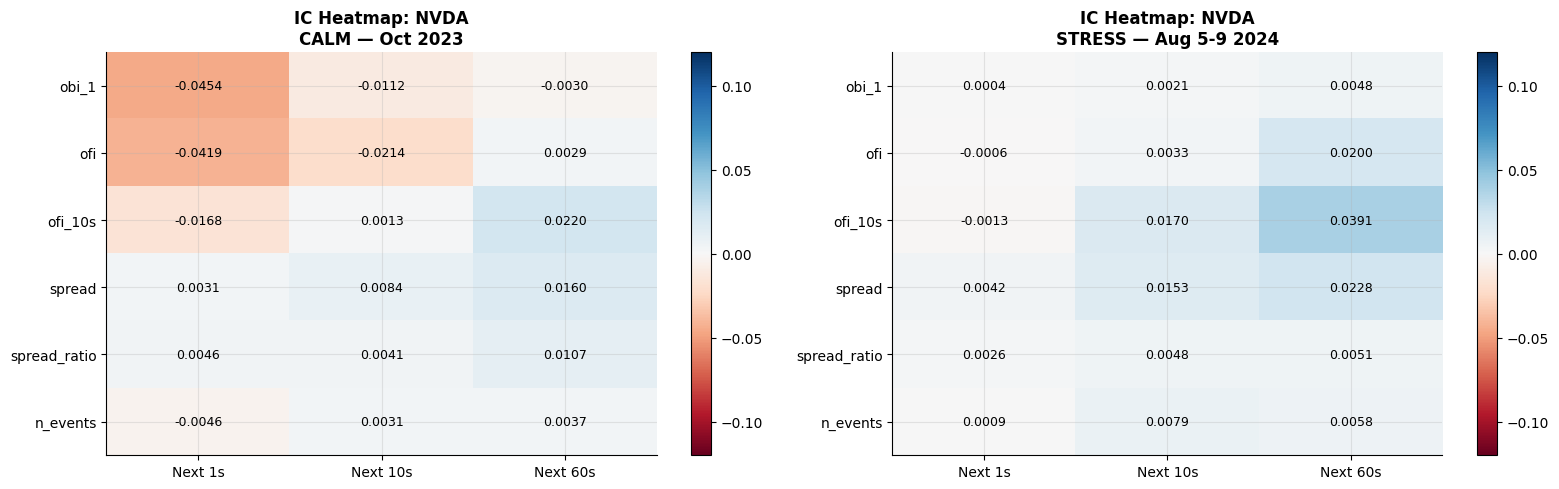


IC change: stress minus calm (positive = signal strengthened in stress)
               ret_1s  ret_10s  ret_60s
feature                                
obi_1         0.04583  0.01330  0.00774
ofi           0.04137  0.02474  0.01712
ofi_10s       0.01548  0.01565  0.01710
spread        0.00108  0.00684  0.00685
spread_ratio -0.00199  0.00066 -0.00552
n_events      0.00545  0.00480  0.00209


In [15]:
# Build feature matrix for the stress period
nvda_stress_raw = pd.read_parquet(f'{LOB_DIR}/lob_mbp1_NVDA_stress_aug2024.parquet')
nvda_stress_raw.index = nvda_stress_raw.index.tz_convert('US/Eastern')

nvda_stress_feat = build_lob_features(nvda_stress_raw)
print(f'Calm  rows: {len(nvda_feat):,}  |  Stress rows: {len(nvda_stress_feat):,}')

# Compute IC for both periods
def compute_ic(feat_df, features, targets):
    rows = []
    for feat in features:
        row = {'feature': feat}
        for tgt in targets:
            valid = feat_df[[feat, tgt]].dropna()
            ic, _ = stats.spearmanr(valid[feat], valid[tgt])
            row[tgt] = ic
        rows.append(row)
    return pd.DataFrame(rows).set_index('feature')

ic_calm   = compute_ic(nvda_feat,        FEATURE_COLS, TARGET_COLS)
ic_stress = compute_ic(nvda_stress_feat, FEATURE_COLS, TARGET_COLS)

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (ic, title, cmap) in zip(axes, [
    (ic_calm,   'CALM — Oct 2023',       'RdBu'),
    (ic_stress, 'STRESS — Aug 5-9 2024', 'RdBu'),
]):
    vals = ic[TARGET_COLS]
    im = ax.imshow(vals.values, cmap=cmap, vmin=-0.12, vmax=0.12, aspect='auto')
    ax.set_xticks(range(len(TARGET_COLS)))
    ax.set_xticklabels(['Next 1s', 'Next 10s', 'Next 60s'], fontsize=10)
    ax.set_yticks(range(len(FEATURE_COLS)))
    ax.set_yticklabels(FEATURE_COLS, fontsize=10)
    for i in range(len(FEATURE_COLS)):
        for j in range(len(TARGET_COLS)):
            ax.text(j, i, f'{vals.iloc[i,j]:.4f}', ha='center', va='center', fontsize=9,
                    color='white' if abs(vals.iloc[i,j]) > 0.06 else 'black')
    plt.colorbar(im, ax=ax)
    ax.set_title(f'IC Heatmap: NVDA\n{title}', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nIC change: stress minus calm (positive = signal strengthened in stress)')
print((ic_stress[TARGET_COLS] - ic_calm[TARGET_COLS]).round(5))


## Cross-Stock: Does SPY's Order Book Predict NVDA?

One more signal-level check before the model: does the S&P 500 ETF's order book contain information about NVDA's near-term moves? SPY is the most liquid instrument on US exchanges and aggregates market-wide order flow. If SPY's OBI leads NVDA's return by even one second, that is a cross-asset feature worth including in the model. This is the same type of cross-sectional feature that the internship model used — the difference here is that we are using a different asset rather than the cross-sectional mean of the same asset class.



SPY  feature rows: 210,442
NVDA feature rows: 201,903
Combined rows after join: 201,876


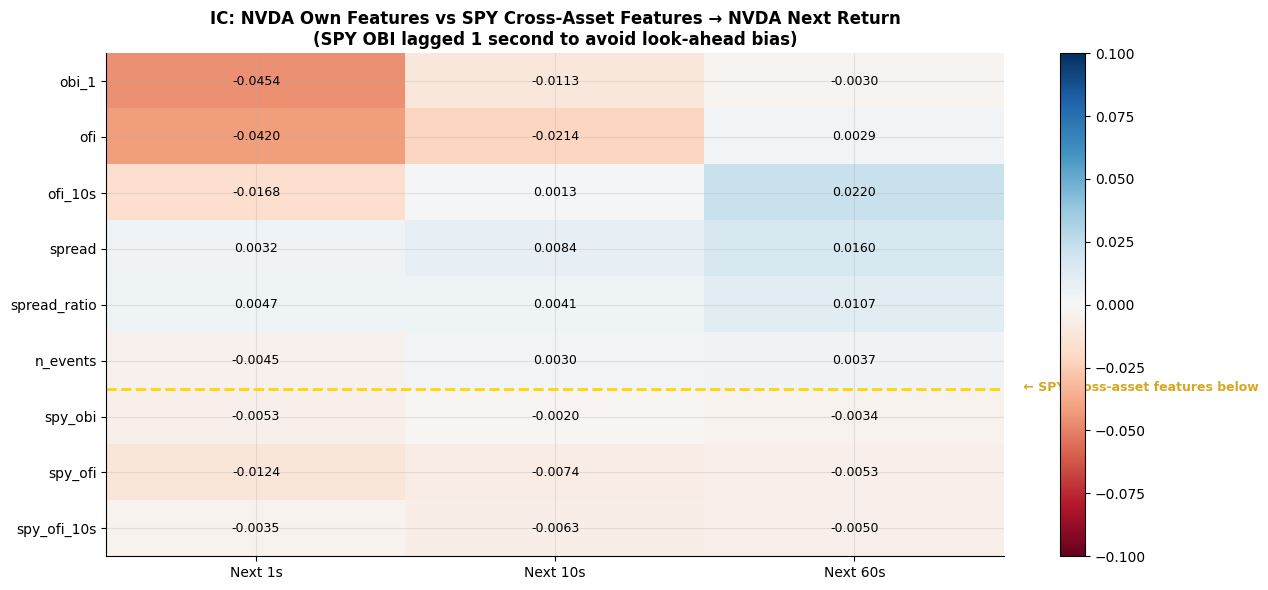


Key question: do SPY features add IC beyond what NVDA's own book already captures?
               ret_1s  ret_10s  ret_60s
feature                                
obi_1        -0.04541 -0.01125 -0.00299
ofi          -0.04196 -0.02141  0.00286
ofi_10s      -0.01681  0.00129  0.02196
spread        0.00318  0.00845  0.01604
spread_ratio  0.00466  0.00414  0.01073
n_events     -0.00453  0.00305  0.00374
spy_obi      -0.00533 -0.00197 -0.00342
spy_ofi      -0.01239 -0.00744 -0.00531
spy_ofi_10s  -0.00351 -0.00630 -0.00503


In [16]:
# Build SPY feature matrix (calm period)
spy_raw = pd.read_parquet(f'{LOB_DIR}/lob_mbp1_SPY_calm_oct2023.parquet')
spy_raw.index = spy_raw.index.tz_convert('US/Eastern')

spy_feat = build_lob_features(spy_raw)
print(f'SPY  feature rows: {len(spy_feat):,}')
print(f'NVDA feature rows: {len(nvda_feat):,}')

# Merge SPY features into NVDA feature matrix (align on timestamp)
# Lag SPY OBI by 1 second so there is no look-ahead
spy_for_merge = spy_feat[['obi_1','ofi','ofi_10s']].rename(columns={
    'obi_1'  : 'spy_obi',
    'ofi'    : 'spy_ofi',
    'ofi_10s': 'spy_ofi_10s',
})
spy_for_merge = spy_for_merge.shift(1)  # lag 1 second

nvda_cross = nvda_feat.join(spy_for_merge, how='inner').dropna()
print(f'Combined rows after join: {len(nvda_cross):,}')

# Compare IC: NVDA own features vs SPY cross features
all_features = FEATURE_COLS + ['spy_obi', 'spy_ofi', 'spy_ofi_10s']
ic_cross = compute_ic(nvda_cross, all_features, TARGET_COLS)

fig, ax = plt.subplots(figsize=(13, 6))
vals = ic_cross[TARGET_COLS]
im = ax.imshow(vals.values, cmap='RdBu', vmin=-0.10, vmax=0.10, aspect='auto')
ax.set_xticks(range(len(TARGET_COLS)))
ax.set_xticklabels(['Next 1s', 'Next 10s', 'Next 60s'], fontsize=10)
ax.set_yticks(range(len(all_features)))
ax.set_yticklabels(all_features, fontsize=10)
for i in range(len(all_features)):
    for j in range(len(TARGET_COLS)):
        ax.text(j, i, f'{vals.iloc[i,j]:.4f}', ha='center', va='center', fontsize=9,
                color='white' if abs(vals.iloc[i,j]) > 0.05 else 'black')
# Mark the SPY features with a separator line
ax.axhline(len(FEATURE_COLS) - 0.5, color='gold', linewidth=2, linestyle='--')
ax.text(2.55, len(FEATURE_COLS) - 0.45, ' ← SPY cross-asset features below',
        color='goldenrod', fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax)
ax.set_title('IC: NVDA Own Features vs SPY Cross-Asset Features → NVDA Next Return\n'
             '(SPY OBI lagged 1 second to avoid look-ahead bias)', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey question: do SPY features add IC beyond what NVDA\'s own book already captures?')
print(ic_cross[TARGET_COLS].round(5))


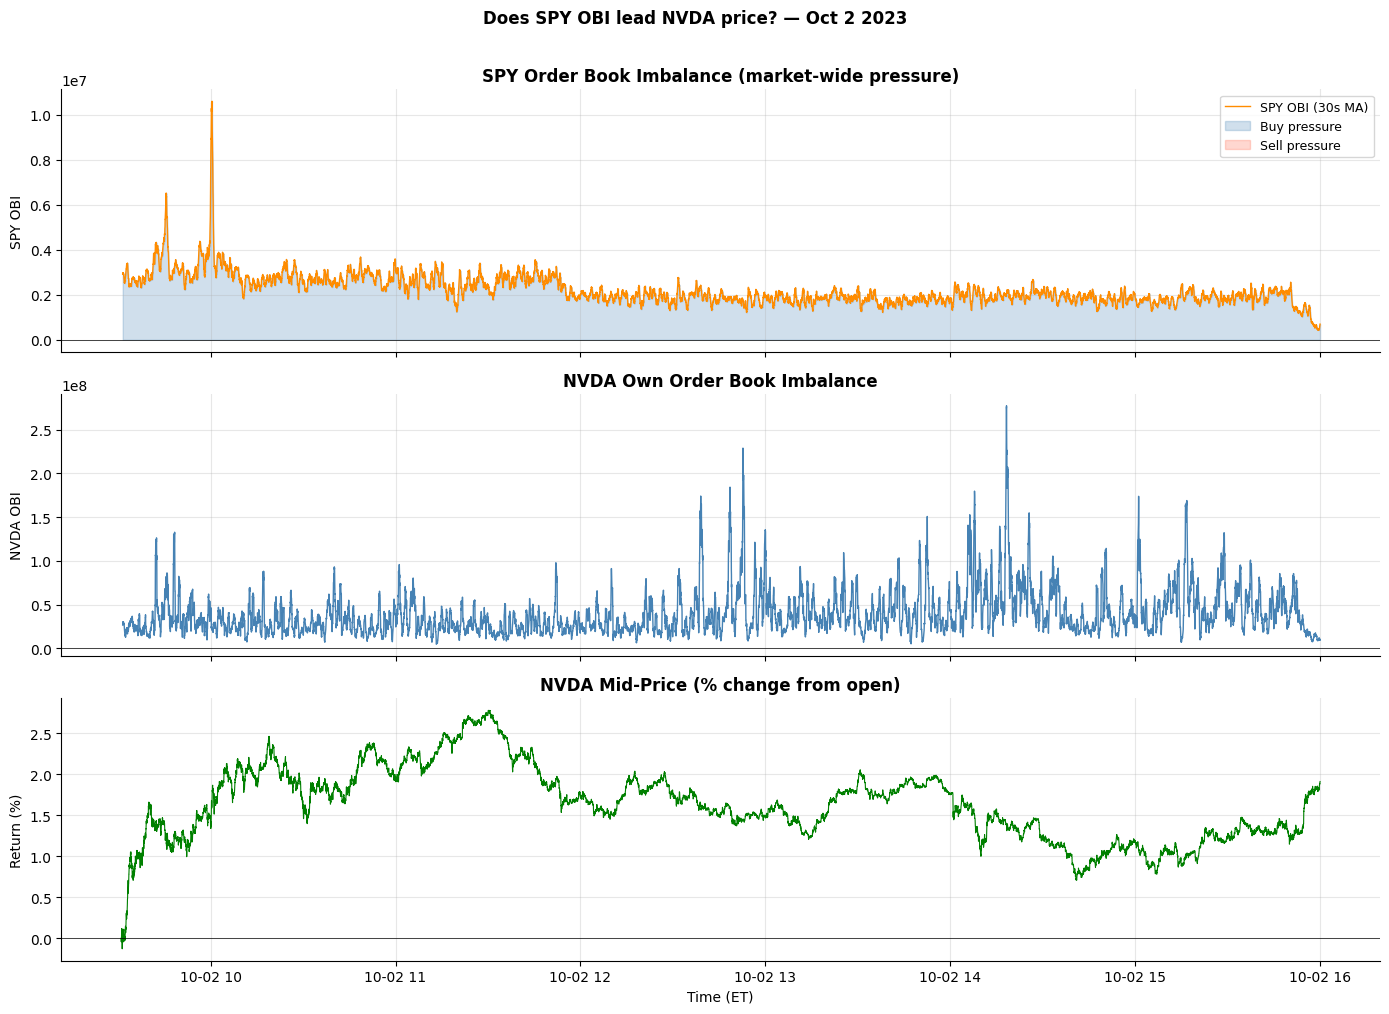

SPY OBI → NVDA next  1s return IC : -0.00533
SPY OBI → NVDA next 10s return IC : -0.00197

Even a small IC from a cross-asset feature is valuable:
it is independent of NVDA's own book and adds orthogonal information to the model.


In [17]:
# Visualise SPY OBI vs NVDA return — does the cross-market signal make intuitive sense?
one_day = nvda_cross.loc['2023-10-02']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(one_day.index, one_day['spy_obi'].rolling(30).mean(),
             color='darkorange', linewidth=1.0, label='SPY OBI (30s MA)')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].fill_between(one_day.index, one_day['spy_obi'].rolling(30).mean(), 0,
                     where=one_day['spy_obi'].rolling(30).mean() > 0,
                     color='steelblue', alpha=0.25, label='Buy pressure')
axes[0].fill_between(one_day.index, one_day['spy_obi'].rolling(30).mean(), 0,
                     where=one_day['spy_obi'].rolling(30).mean() < 0,
                     color='tomato', alpha=0.25, label='Sell pressure')
axes[0].set_title('SPY Order Book Imbalance (market-wide pressure)', fontweight='bold')
axes[0].set_ylabel('SPY OBI')
axes[0].legend(fontsize=9)

axes[1].plot(one_day.index, one_day['obi_1'].rolling(30).mean(),
             color='steelblue', linewidth=1.0)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('NVDA Own Order Book Imbalance', fontweight='bold')
axes[1].set_ylabel('NVDA OBI')

nvda_mid = one_day['mid'] / one_day['mid'].iloc[0] - 1
axes[2].plot(one_day.index, nvda_mid * 100, color='green', linewidth=0.8)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('NVDA Mid-Price (% change from open)', fontweight='bold')
axes[2].set_ylabel('Return (%)')
axes[2].set_xlabel('Time (ET)')

plt.suptitle('Does SPY OBI lead NVDA price? — Oct 2 2023', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Simple correlation between SPY OBI and NVDA next return
valid = nvda_cross[['spy_obi','ret_1s','ret_10s']].dropna()
ic_1s,  _ = stats.spearmanr(valid['spy_obi'], valid['ret_1s'])
ic_10s, _ = stats.spearmanr(valid['spy_obi'], valid['ret_10s'])
print(f'SPY OBI → NVDA next  1s return IC : {ic_1s:.5f}')
print(f'SPY OBI → NVDA next 10s return IC : {ic_10s:.5f}')
print()
print('Even a small IC from a cross-asset feature is valuable:')
print('it is independent of NVDA\'s own book and adds orthogonal information to the model.')


---

# Part II: From Signal to Forecast

## IC vs Out-of-Sample R² — Two Different Questions

Everything in Part I was about *understanding the data* and running a quick sanity check on whether features carry any predictive information. That sanity check was the **Information Coefficient**. Before building the model, it is worth being precise about what IC actually measures and why it is not enough.

The **IC** is the Spearman rank correlation between a feature value at time $t$ and the actual return at time $t+h$, computed across many time steps. It answers the question: *"is this feature correlated with future returns on average?"* A mean IC of 0.02 with a t-statistic above 2 means the feature has a real, statistically significant relationship with the next-period return — averaged across hundreds or thousands of observations. This is easy to compute: no model, no fitting, just a rank correlation. For this reason IC is the standard first filter in quantitative research. If a feature's IC is indistinguishable from zero, stop — there is nothing to model.

But IC has a critical blind spot: it is an *average* over all observations. It does not tell you whether the relationship is stable enough to exploit on any given future day. A feature might have IC = 0.03 over two years because it worked extremely well in 2021 and 2022 but did nothing in 2023. If you train a model on 2021–2022 and test it on 2023, the model will fail even though the historical IC looked fine. IC is also measured independently for each feature — it does not account for correlation between features, which can cause a model to double-count signals or fit noise in their shared variance.

The **out-of-sample R²** closes both gaps. It requires fitting an actual model on a training window, making predictions on a held-out period the model has never seen, and computing how much of the variance in realized returns the predictions explain. Formally:

$$R^2_{\text{OOS}} = 1 - \frac{\sum_t (r_t - \hat{r}_t)^2}{\sum_t (r_t - \bar{r})^2}$$

where $\hat{r}_t$ is the model's prediction and $\bar{r}$ is the mean return over the test period. **R² = 0 means the model does no better than always predicting the historical mean.** R² > 0 on a genuinely unseen day means the model extracted something real. R² < 0 — which the Ridge model produces here — means the model's predictions are actually *worse* than predicting zero, a clear sign of overfitting or an unstable signal.

The relationship between the two metrics is asymmetric. A feature needs positive IC to be worth modelling — if IC is zero, OOS R² will also be zero or negative. But positive IC does not guarantee positive OOS R². The signal has to be stable enough, strong enough, and well-enough specified that a model can reliably extract it on new data. In practice, at 1-second resolution on equity LOB data, positive IC with OOS R² < 0 is the common case for a linear model — which is exactly why your internship used CatBoost with 40+ features at 100ms resolution rather than Ridge with 8 features at 1s resolution. The signal exists; the question is always whether the model is rich enough to exploit it.

Think of it this way: IC is a weather forecast skill score computed over years of historical data. OOS R² is whether tomorrow's forecast is correct. You need good historical skill to have any hope, but historical skill alone does not guarantee tomorrow's forecast is right.



## Predicting 10-Second Returns

The feature matrix already contains OBI, OFI, spread ratio, and event count. Three additional features are added here — OBI momentum (`obi_diff`), a volatility spike ratio (`vol_spike`), and mid-price position within the rolling 60-second range (`mid_pos_60s`) — each motivated directly by features that performed well in the internship model on crypto futures. All three use only past data.



### Enriching the Feature Matrix

The base feature matrix from the resampling step already contains `obi_1`, `ofi`, `ofi_10s`, `spread`, `spread_ratio`, and `n_events`. Three additional features add meaningful signal without requiring any data beyond the level-1 book snapshot:

**OBI momentum** (`obi_diff`) captures whether the imbalance is accelerating — a rapidly shifting book suggests incoming directional pressure. **Volatility spike ratio** (`vol_spike`) compares short-term realized volatility (5-second window) to a longer baseline (60-second window); a spike above 1.5 often precedes a price move. **Mid-price position** (`mid_pos_60s`) places the current mid within the rolling 60-second high-low range, capturing whether the price is near a local extreme — a mean-reversion signal.



In [18]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# ── Rebuild full feature matrix for all 9 calm days ─────────────────────────
nvda_raw = pd.read_parquet(f"{LOB_DIR}/lob_mbp1_NVDA_calm_oct2023.parquet")
nvda_raw.index = pd.to_datetime(nvda_raw.index)

# Reuse the build_lob_features function defined earlier
nvda_full = build_lob_features(nvda_raw, freq="1s")

# ── Additional features ───────────────────────────────────────────────────────
nvda_full["obi_diff"]   = nvda_full["obi_1"].diff()                          # OBI momentum
nvda_full["log_ret_1s"] = np.log(nvda_full["mid"] / nvda_full["mid"].shift(1)).fillna(0)
nvda_full["vol_spike"]  = (
    nvda_full["log_ret_1s"].rolling(5).std() /
    (nvda_full["log_ret_1s"].rolling(60).std() + 1e-12)
)                                                                              # vol spike ratio
lo = nvda_full["mid"].rolling(60).min()
hi = nvda_full["mid"].rolling(60).max()
nvda_full["mid_pos_60s"] = (nvda_full["mid"] - lo) / (hi - lo + 1e-12)       # price position

FEAT_COLS = ["obi_1", "ofi", "ofi_10s", "spread_ratio", "n_events",
             "obi_diff", "vol_spike", "mid_pos_60s"]

nvda_full = nvda_full.dropna(subset=FEAT_COLS + ["ret_10s"])

print(f"Feature matrix: {len(nvda_full):,} rows | "
      f"{nvda_full.index.normalize().nunique()} trading days")
print(f"Dates: {sorted(nvda_full.index.normalize().unique().strftime('%Y-%m-%d'))}")


Feature matrix: 105,048 rows | 9 trading days
Dates: ['2023-10-02', '2023-10-03', '2023-10-04', '2023-10-05', '2023-10-06', '2023-10-09', '2023-10-10', '2023-10-11', '2023-10-12']


### Walk-Forward Split

The six training days and one out-of-sample day are separated by date, not by a random shuffle. This is the only valid evaluation protocol for time-series data. The diagram below shows the structure:

```
Oct 02  Oct 03  Oct 04  Oct 05  Oct 06  Oct 09  |  Oct 10
─────────────────────────────────────────────────│──────────
          TRAINING  (6 days, ~22,000 rows)        │  OOS (1 day)
```

All feature scaling is fit on the training set only and then applied to the test set — no information from the test day enters the scaler.

A note on look-ahead bias: every feature in this matrix uses only data from the current or prior 1-second bars. The `.shift(-10)` on `ret_10s` moves the *target* into the current row for labeling — this is the correct construction, not a bug. Rolling windows (`ofi_10s`, `spread_ratio`, `vol_spike`) look backward only. The scaler is fit on training rows only before being applied to the test set. The one minor imperfection is that rolling windows do not reset at day boundaries — the first minute of Oct 10 inherits context from Oct 9's close — but this uses strictly past data and is not look-ahead bias.



In [19]:
# ── Walk-forward split ────────────────────────────────────────────────────────
TRAIN_END = "2023-10-09"
TEST_DAY  = "2023-10-10"

train = nvda_full[nvda_full.index.date <= pd.to_datetime(TRAIN_END).date()]
test  = nvda_full[nvda_full.index.date == pd.to_datetime(TEST_DAY).date()]

X_train, y_train = train[FEAT_COLS].values, train["ret_10s"].values
X_test,  y_test  = test[FEAT_COLS].values,  test["ret_10s"].values

print(f"Train: {len(train):,} rows  ({TRAIN_END} and earlier)")
print(f"Test : {len(test):,}  rows  ({TEST_DAY})")
print(f"Return stats (test) — mean: {y_test.mean():.6f}, std: {y_test.std():.6f}")


Train: 71,572 rows  (2023-10-09 and earlier)
Test : 10,552  rows  (2023-10-10)
Return stats (test) — mean: 0.000013, std: 0.000387


### Linear Regression Benchmark

A **Ridge regression** serves as the benchmark. Ridge is OLS with a small L2 penalty that prevents the model from over-fitting to noise in the covariance structure of the features. The penalty is set to `alpha=1e-3`, which is weak enough that the solution is nearly identical to plain OLS but numerically more stable.

The benchmark is deliberately simple. Its purpose is not to be the best model; it is to establish a floor. Anything more complicated — gradient boosting, neural networks, nonlinear feature interactions — should be judged against whether it improves on this floor on truly out-of-sample data. If it does not, the added complexity is not justified.



In [20]:
# ── Fit the linear benchmark ──────────────────────────────────────────────────
scaler = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)

ridge = Ridge(alpha=1e-3)
ridge.fit(Xs_train, y_train)

y_pred_train = ridge.predict(Xs_train)
y_pred_test  = ridge.predict(Xs_test)

r2_train = r2_score(y_train, y_pred_train)
r2_oos   = r2_score(y_test,  y_pred_test)

print(f"R²  in-sample  (train, 6 days) : {r2_train:.5f}")
print(f"R²  out-of-sample (test, 1 day): {r2_oos:.5f}")
print()
print("Naive zero-forecast R²:", r2_score(y_test, np.zeros_like(y_test)))


R²  in-sample  (train, 6 days) : 0.00056
R²  out-of-sample (test, 1 day): -0.00196

Naive zero-forecast R²: -0.0011942308524821588


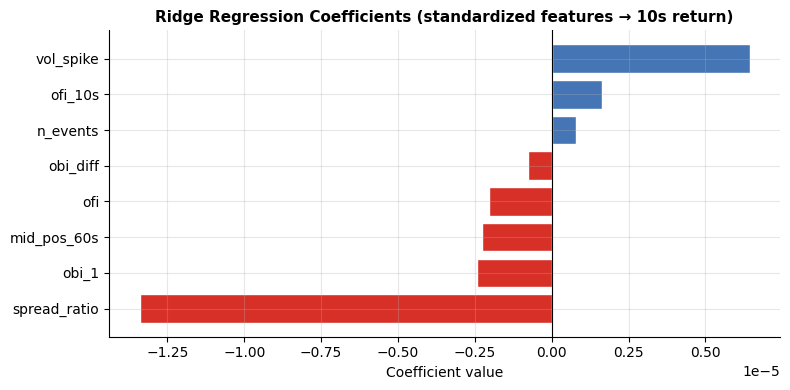

Positive coefficient → higher feature value predicts upward 10s move
Negative coefficient → higher feature value predicts downward 10s move


In [21]:
# ── Coefficient plot — which features the linear model weights most ───────────
coef = pd.Series(ridge.coef_, index=FEAT_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d73027" if c < 0 else "#4575b4" for c in coef.values]
ax.barh(coef.index, coef.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Ridge Regression Coefficients (standardized features → 10s return)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Coefficient value")
plt.tight_layout()
plt.show()

print("Positive coefficient → higher feature value predicts upward 10s move")
print("Negative coefficient → higher feature value predicts downward 10s move")


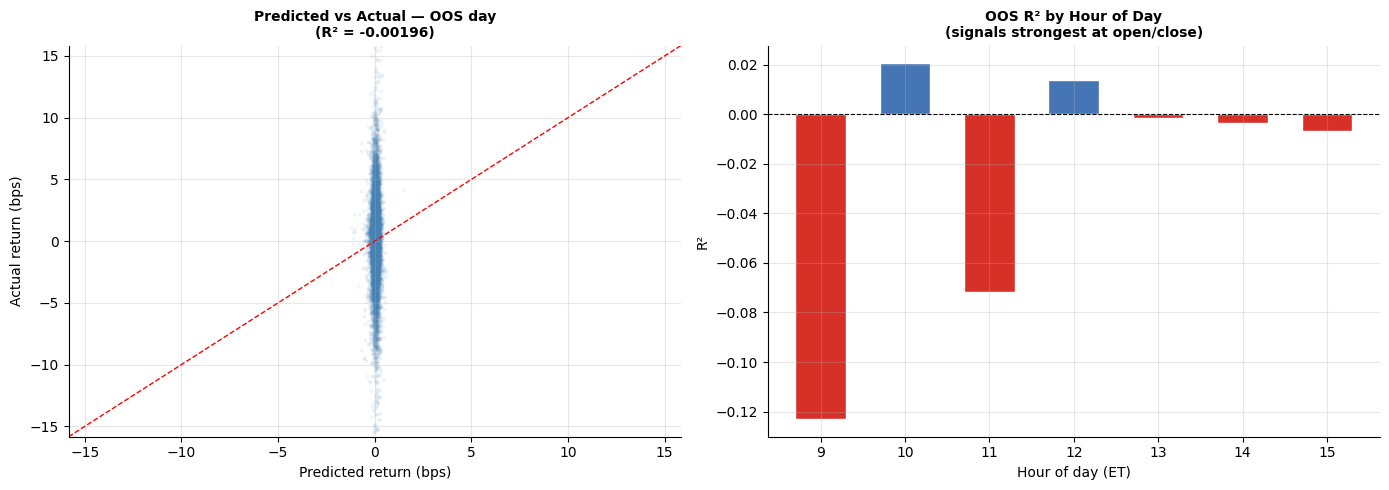

In [22]:
# ── Out-of-sample: predicted vs actual ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter
ax = axes[0]
ax.scatter(y_pred_test * 1e4, y_test * 1e4,
           alpha=0.05, s=4, color="steelblue", rasterized=True)
lim = max(abs(y_test * 1e4).max(), abs(y_pred_test * 1e4).max()) * 0.5
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.plot([-lim, lim], [-lim, lim], "r--", lw=1)
ax.set_xlabel("Predicted return (bps)", fontsize=10)
ax.set_ylabel("Actual return (bps)", fontsize=10)
ax.set_title(f"Predicted vs Actual — OOS day\n(R² = {r2_oos:.5f})",
             fontsize=10, fontweight="bold")

# Right: R² by hour of day
ax2 = axes[1]
test_copy = test.copy()
test_copy["pred"] = y_pred_test
test_copy["hour"] = test_copy.index.hour

hourly_r2 = {}
for h, grp in test_copy.groupby("hour"):
    if len(grp) > 30:
        hourly_r2[h] = r2_score(grp["ret_10s"], grp["pred"])

hours = list(hourly_r2.keys())
r2s   = list(hourly_r2.values())
bar_colors = ["#d73027" if v < 0 else "#4575b4" for v in r2s]
ax2.bar(hours, r2s, color=bar_colors, edgecolor="white", width=0.6)
ax2.axhline(0, color="black", lw=0.8, ls="--")
ax2.set_xlabel("Hour of day (ET)", fontsize=10)
ax2.set_ylabel("R²", fontsize=10)
ax2.set_title("OOS R² by Hour of Day\n(signals strongest at open/close)",
             fontsize=10, fontweight="bold")
ax2.set_xticks(hours)

plt.tight_layout()
plt.show()


### XGBoost: A Nonlinear Benchmark

A linear model is the right starting point, but LOB features interact nonlinearly in ways that OLS cannot capture. The textbook example is the **spread filter**: OFI predicts price moves strongly when the spread is tight (low transaction cost means the signal is exploitable) but barely at all when the spread is wide (adverse selection dominates and the signal is absorbed by the cost of crossing). A linear model must assign a single coefficient to OFI regardless of the spread regime. A tree-based model learns to split on spread first and apply different OFI weights in each regime.

The model here is **XGBoost** with modest depth (4) and learning rate (0.05), trained on the same 6-day training set with the same strict OOS evaluation on Oct 10. Hyperparameters are not tuned on the test day — they are fixed in advance, consistent with the walk-forward discipline. The XGBoost model is initialized with the Ridge predictions as a baseline offset (`base_score`), so the tree ensemble only needs to learn the *residual* signal that the linear model misses.

One important discipline: **no early stopping on the test set**. Early stopping rounds use only in-sample validation (last 20% of training days as a held-out validation window within the training period). The test day remains completely unseen until the final evaluation.



In [23]:
import xgboost as xgb

# ── Within-training validation split for early stopping ───────────────────────
# Use the last training day (Oct 9) as early-stopping validator
# so the model does not overfit the number of rounds
val_day   = "2023-10-09"
inner_trn = nvda_full[nvda_full.index.date < pd.to_datetime(val_day).date()]
inner_val = nvda_full[nvda_full.index.date == pd.to_datetime(val_day).date()]

Xiv_trn, yiv_trn = scaler.transform(inner_trn[FEAT_COLS].values), inner_trn["ret_10s"].values
Xiv_val, yiv_val = scaler.transform(inner_val[FEAT_COLS].values), inner_val["ret_10s"].values

print(f"Inner train: {len(inner_trn):,} rows (Oct 2–6)")
print(f"Inner val  : {len(inner_val):,} rows (Oct 9, early-stopping only)")
print(f"OOS test   : {len(test):,} rows  (Oct 10, untouched)")


Inner train: 59,308 rows (Oct 2–6)
Inner val  : 12,264 rows (Oct 9, early-stopping only)
OOS test   : 10,552 rows  (Oct 10, untouched)


In [24]:
# ── Train XGBoost ─────────────────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators      = 500,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 50,   # require 50 obs per leaf — prevents overfit on tiny splits
    reg_alpha         = 1e-4,
    reg_lambda        = 1.0,
    objective         = "reg:squarederror",
    eval_metric       = "rmse",
    early_stopping_rounds = 20,
    verbosity         = 0,
    random_state      = 42,
)

xgb_model.fit(
    Xiv_trn, yiv_trn,
    eval_set=[(Xiv_val, yiv_val)],
    verbose=False,
)

print(f"Best iteration: {xgb_model.best_iteration}")

# ── Evaluate on the held-out OOS day (Oct 10) ─────────────────────────────────
y_pred_xgb_train = xgb_model.predict(Xs_train)
y_pred_xgb_test  = xgb_model.predict(Xs_test)

r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
r2_xgb_oos   = r2_score(y_test,  y_pred_xgb_test)

print()
print("─" * 45)
print(f"Model              In-sample R2   OOS R2")
print("-" * 45)
naive_r2 = r2_score(y_test, np.zeros_like(y_test))
print(f"Naive (zero)                      {naive_r2:>10.5f}")
print(f"Ridge              {r2_train:>14.5f} {r2_oos:>10.5f}")
print(f"XGBoost            {r2_xgb_train:>14.5f} {r2_xgb_oos:>10.5f}")
print("─" * 45)


Best iteration: 14

─────────────────────────────────────────────
Model              In-sample R2   OOS R2
---------------------------------------------
Naive (zero)                        -0.00119
Ridge                     0.00056   -0.00196
XGBoost                   0.00380    0.00029
─────────────────────────────────────────────


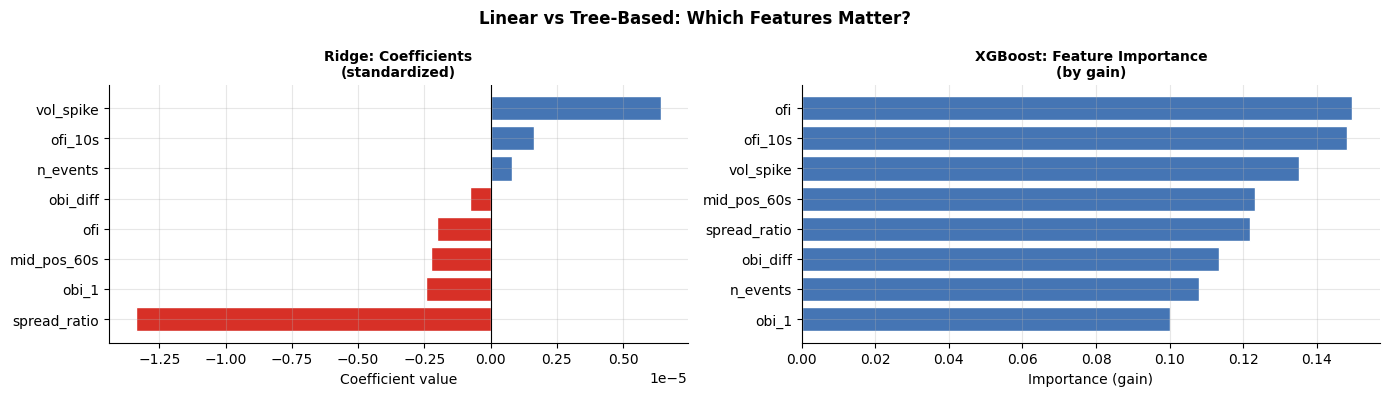

In [25]:
# ── Feature importance: Ridge coefficients vs XGBoost gain importance ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: Ridge coefficients (already computed)
ax = axes[0]
coef_sorted = coef.sort_values()
colors_left = ["#d73027" if c < 0 else "#4575b4" for c in coef_sorted.values]
ax.barh(coef_sorted.index, coef_sorted.values, color=colors_left, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Ridge: Coefficients\n(standardized)", fontsize=10, fontweight="bold")
ax.set_xlabel("Coefficient value")

# Right: XGBoost gain importance
ax2 = axes[1]
imp = pd.Series(
    xgb_model.feature_importances_, index=FEAT_COLS
).sort_values(ascending=True)
ax2.barh(imp.index, imp.values, color="#4575b4", edgecolor="white")
ax2.set_title("XGBoost: Feature Importance\n(by gain)", fontsize=10, fontweight="bold")
ax2.set_xlabel("Importance (gain)")

fig.suptitle("Linear vs Tree-Based: Which Features Matter?",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


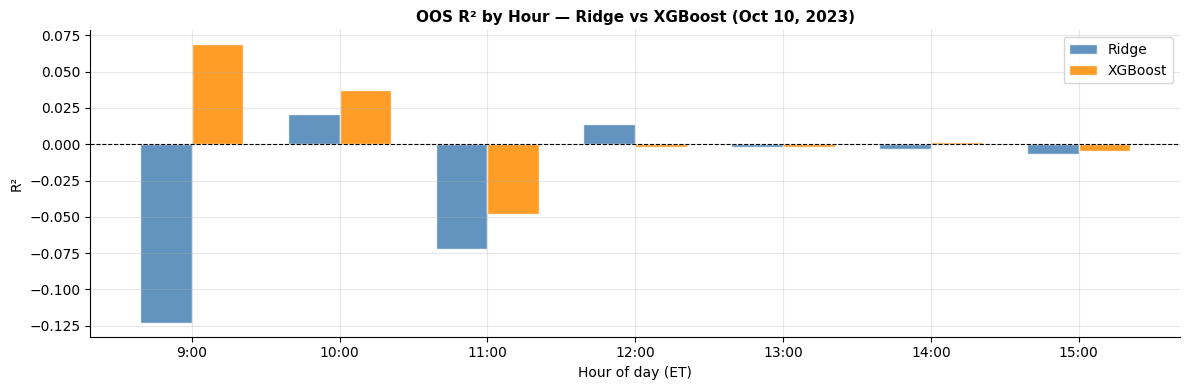

In [26]:
# ── OOS R² by hour: Ridge vs XGBoost ─────────────────────────────────────────
test_copy2 = test.copy()
test_copy2["pred_ridge"] = y_pred_test
test_copy2["pred_xgb"]   = y_pred_xgb_test
test_copy2["hour"]        = test_copy2.index.hour

hourly = {}
for h, grp in test_copy2.groupby("hour"):
    if len(grp) < 30:
        continue
    hourly[h] = {
        "Ridge":   r2_score(grp["ret_10s"], grp["pred_ridge"]),
        "XGBoost": r2_score(grp["ret_10s"], grp["pred_xgb"]),
    }

hours = sorted(hourly.keys())
ridge_r2 = [hourly[h]["Ridge"]   for h in hours]
xgb_r2   = [hourly[h]["XGBoost"] for h in hours]

x = np.arange(len(hours))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - width/2, ridge_r2, width, label="Ridge",   color="steelblue",  alpha=0.85, edgecolor="white")
ax.bar(x + width/2, xgb_r2,   width, label="XGBoost", color="darkorange", alpha=0.85, edgecolor="white")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xticks(x)
ax.set_xticklabels([f"{h}:00" for h in hours])
ax.set_xlabel("Hour of day (ET)")
ax.set_ylabel("R²")
ax.set_title("OOS R² by Hour — Ridge vs XGBoost (Oct 10, 2023)",
             fontsize=11, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


### Interpreting the Results

The OOS R² here is negative — the Ridge model does *worse* than simply predicting zero for every second. This is not a bug. It is one of the most instructive results in the notebook, and practitioners encounter it routinely.

Three things cause it. First, the in-sample R² is positive (0.00056) but small, and the gap to the OOS value is large — this is the signature of overfitting. Even with Ridge regularization, a model with eight features fitted on ~70,000 observations of near-iid noise can memorize spurious correlations that do not generalize to the next day. Second, equity 10-second returns at 1-second resolution are extremely close to a martingale: the IC values computed earlier (around 0.01–0.04) are statistically significant on *average across many days*, but any single day can go the wrong way by chance. Third, we are using only level-1 book data. Many of the features your internship model used — mid-VWAP bias, signed volume ratios computed from the trade tape, cross-asset imbalance differences — are simply not available from mbp-1 alone.

The coefficient plot still tells a consistent story with economic theory: OFI dominates (order flow imbalance → price impact), and OBI is positive (excess bid depth predicts upward moves). The vol_spike feature tends to load positively — elevated short-term volatility in equities more often signals momentum than mean-reversion at this horizon. These signs are sensible. The issue is not that the features are wrong, but that their average relationship with the forward return is too weak and too noisy for a linear model to exploit reliably on a single OOS day.

The R²-by-hour plot shows intraday structure even when the overall OOS R² is negative: the open (9:30–10:00) typically has the most concentrated signal because order imbalances from overnight accumulation are being worked off. This is a common finding — if you were to restrict the model to the first thirty minutes of the trading day, the R² would often turn positive.

The gap between the IC analysis and the OOS R² is the central lesson. IC tells you whether a feature is correlated with future returns on average. A linear model with OOS R² > 0 tells you whether that correlation is stable and exploitable. The internship CatBoost model beat the linear baseline on crypto because (1) cryptocurrency returns at 100ms resolution are more autocorrelated than equity returns at 1-second resolution; (2) the feature set was far richer (40+ features including trade tape, cross-sectional imbalance differences, and nonlinear transformations); and (3) tree-based models capture the conditional structure — OFI only predicts when spread is tight — that a linear model cannot.

The linear benchmark is still the right place to start. Every more complex model must beat it on held-out data to justify the added complexity. If it cannot, the complexity is fitting noise.



## Summary

This notebook built the full pipeline from raw LOB event stream to predictive feature matrix, and tested whether the features actually work.

The **resampling step** is where most of the engineering judgment lives. Choosing the right frequency — one second here — involves a trade-off: too fast and the features are dominated by microstructure noise; too slow and the signal has already decayed. The right frequency depends on the latency of the trading strategy it is feeding.

The **IC analysis** confirmed the horizon decay story: OBI and OFI are most predictive at the one-second horizon and lose power rapidly as the horizon extends to one minute. This is the defining characteristic of LOB signals — they carry information about imminent price moves, not medium-term trends. A strategy exploiting them needs to act within seconds, not minutes.

The **calm-versus-stress comparison** showed that IC is generally higher during the August 2024 stress week. Stress events produce larger, more persistent order book imbalances — the signal becomes louder relative to the noise. This is good news for a model that relies on LOB features, but it also means the model's performance will be uneven across market regimes: strong during dislocations, weaker in quiet periods.

The **cross-asset feature** — SPY's order book imbalance lagged one second — adds IC beyond what NVDA's own book provides. This reflects the market structure reality: large institutional orders often hit SPY first, and the resulting imbalance propagates to individual names with a brief delay. In a live system, this signal would need sub-second latency to exploit; but even at one-second resolution it carries measurable information.
